In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
import json

# Load TSV result files
tsv_files = glob("../results/**/*_test_ner_temporal_entity_scores.tsv", recursive=True)
print(len(tsv_files))
for tsv in tsv_files:
    if "False" in tsv and "historic" in tsv:
        print(tsv, '\n')

def clean_model_name(raw_name):
    base = raw_name.replace("_test_ner_temporal_entity_scores.tsv", "")
    parts = base.split("_")
    try:
        model_type = parts[-1]
        model_size = parts[2] + '-' + parts[3]
        max_len = parts[-5]
        return f"{model_type}-{model_size}-{max_len}"
    except Exception:
        return raw_name

def get_model_type(raw_name):
    base = raw_name.replace("_test_ner_temporal_entity_scores.tsv", "")
    parts = base.split("_")
    try:
        index_run = parts.index("run")
        return parts[index_run + 1].replace('time-swiglu.', '')
    except Exception:
        return raw_name

def get_max_len(raw_name):
    base = raw_name.replace("_test_ner_temporal_entity_scores.tsv", "")
    parts = base.split("_")
    try:
        return parts[-5]
    except Exception:
        return raw_name

def get_base_model(raw_name):
    base = raw_name.replace("_test_ner_temporal_entity_scores.tsv", "")
    parts = base.split("_")
    try:
        return '_'.join(parts[1:5])  # include 1–4 index
    except Exception:
        return raw_name

# Load and annotate result TSVs
all_dfs = []
for file in tsv_files:
    df = pd.read_csv(file, sep="\t")
    df["run"] = os.path.basename(file).replace("_test_ner_temporal_entity_scores.tsv", "")
    df["run_clean"] = clean_model_name(df["run"].iloc[0])
    df["strategy"] = get_model_type(df["run"].iloc[0])
    df["max_len"] = get_max_len(df["run"].iloc[0])
    df["base_model"] = get_base_model(df["run"].iloc[0])
    all_dfs.append(df)

results_df = pd.concat(all_dfs, ignore_index=True)
print(results_df.head())

results_df["strategy"] = results_df["strategy"].apply(lambda x: x.split('.')[0])
print(results_df['strategy'].unique())

if "relative_year" not in results_df.columns:
    results_df['relative_year'] = results_df['run'].str.extract(r'(True|False)$')[0]
print(results_df['relative_year'].unique())


results_df["relative_year"] = results_df["relative_year"].astype(str).str.lower() == "true"
results_df["temporal_mode"] = results_df["relative_year"].map({True: "Time Distance", False: "Absolute"})

print(results_df['relative_year'].unique())
print(results_df['temporal_mode'].unique())

mapping_model = {'relative': 'Late Fusion Strategies',
                 'concat': 'Late Fusion Strategies',
                 'adapter': 'Late Fusion Strategies',
                 'baseline': 'Baseline',
                 'early-cross-attention': 'Early Fusion Strategies',
                 'late-cross-attention': 'Late Fusion Strategies',}

results_df["strategy_type"] = results_df["strategy"].apply(lambda x: mapping_model[x])

results_df = results_df[results_df["strategy"] != "film"]

# Load one matching JSON file from subfolder
csv_files = glob("../results/**/entity_statistics_test.tsv", recursive=True)
if csv_files:
    entity_stats_df = pd.read_csv(csv_files[0], sep="\t")
    entity_stats_df["entity_type"] = entity_stats_df["entity_type"].str.lower()

    # Compute micro average (sum of all entity counts per year for the test split)
micro_avg_df = (
    entity_stats_df[entity_stats_df["split"] == "test"]
    .groupby("year", as_index=False)["count"]
    .sum()
)
micro_avg_df["entity_type"] = "micro avg"
micro_avg_df["split"] = "test"

# Append to entity_stats_df
entity_stats_df = pd.concat([entity_stats_df, micro_avg_df], ignore_index=True)


24
../results/model_dbmdz_bert_base_historic_multilingual_cased_max_sequence_length_512_epochs_3_run_time-swiglu.concat.False/model_dbmdz_bert_base_historic_multilingual_cased_max_sequence_length_512_epochs_3_run_time-swiglu.concat.False_test_ner_temporal_entity_scores.tsv 

../results/model_dbmdz_bert_base_historic_multilingual_cased_max_sequence_length_512_epochs_3_run_time-swiglu.baseline.False/model_dbmdz_bert_base_historic_multilingual_cased_max_sequence_length_512_epochs_3_run_time-swiglu.baseline.False_test_ner_temporal_entity_scores.tsv 

../results/model_dbmdz_bert_base_historic_multilingual_cased_max_sequence_length_512_epochs_3_run_time-swiglu.early-cross-attention.False/model_dbmdz_bert_base_historic_multilingual_cased_max_sequence_length_512_epochs_3_run_time-swiglu.early-cross-attention.False_test_ner_temporal_entity_scores.tsv 

../results/model_dbmdz_bert_base_historic_multilingual_cased_max_sequence_length_512_epochs_3_run_time-swiglu.adapter.False/model_dbmdz_bert_bas

In [118]:
from itertools import product

# Strategy names
strategies = [
    'baseline', 'adapter', 'concat',
    'relative', 'early-cross-attention', 'late-cross-attention'
]

# Base models
base_models = [
    'bert_base_multilingual_cased',
    'dbmdz_bert_base_historic_multilingual_cased'
]

# Temporal modes (as strings)
temporal_modes = ['True', 'False']

# Build expected set of tuples (strategy, base_model, temporal_mode)
expected = set(product(strategies, base_models, temporal_modes))

# Initialize actual combinations found in tsv filenames
actual = set()

# Extract actual combinations
for path in tsv_files:
    base_model = (
        'dbmdz_bert_base_historic_multilingual_cased'
        if 'historic' in path else 'bert_base_multilingual_cased'
    )

    for strategy in strategies:
        if f"time-swiglu.{strategy}." in path:
            break
    else:
        strategy = "unknown"

    if "True" in path:
        relative = "True"
    elif "False" in path:
        relative = "False"
    else:
        relative = "unknown"

    actual.add((strategy, base_model, relative))

# Find missing combinations
missing = expected - actual

# Print missing ones
print(f"\n✅ Total expected: {len(expected)}\n🟢 Found: {len(actual)}\n❌ Missing: {len(missing)}\n")
for strat, model, rel in sorted(missing):
    print(f"Missing: strategy={strat:22} base_model={model:40} temporal_mode={rel}")


✅ Total expected: 24
🟢 Found: 24
❌ Missing: 0



In [119]:
# Check for baseline strategies and their associated temporal modes
baseline_modes = results_df[results_df["strategy_type"] == "Baseline"]["temporal_mode"].value_counts()
print("Baseline temporal modes:\n", baseline_modes)

# Optionally, list unique runs for baseline
baseline_runs = results_df[results_df["strategy_type"] == "Baseline"]["run"].unique()
print("\nUnique baseline runs:\n", baseline_runs)

Baseline temporal modes:
 temporal_mode
Time Distance    474
Absolute         472
Name: count, dtype: int64

Unique baseline runs:
 ['model_bert_base_multilingual_cased_max_sequence_length_512_epochs_3_run_time-swiglu.baseline.True'
 'model_dbmdz_bert_base_historic_multilingual_cased_max_sequence_length_512_epochs_3_run_time-swiglu.baseline.False'
 'model_bert_base_multilingual_cased_max_sequence_length_512_epochs_3_run_time-swiglu.baseline.False'
 'model_dbmdz_bert_base_historic_multilingual_cased_max_sequence_length_512_epochs_3_run_time-swiglu.baseline.True']


In [120]:
# Step 1: Identify baseline rows
baseline_df = results_df[
    (results_df["strategy_type"] == "Baseline") &
    (results_df["run"].str.endswith(".False"))
]

# Step 2: Keep all non-baseline results
non_baseline_df = results_df[results_df["strategy_type"] != "Baseline"]

# Step 3: Merge them back
results_df_cleaned = pd.concat([non_baseline_df, baseline_df], ignore_index=True)

# Step 4: Normalize temporal_mode for baseline
results_df_cleaned.loc[
    results_df_cleaned["strategy_type"] == "Baseline", "temporal_mode"
] = "No Temporal Info"

# Optional: confirm baseline uniqueness
print("Unique baseline runs:\n", results_df_cleaned[results_df_cleaned["strategy_type"] == "Baseline"]["run"].unique())
print("Temporal modes:\n", results_df_cleaned["temporal_mode"].unique())

Unique baseline runs:
 ['model_dbmdz_bert_base_historic_multilingual_cased_max_sequence_length_512_epochs_3_run_time-swiglu.baseline.False'
 'model_bert_base_multilingual_cased_max_sequence_length_512_epochs_3_run_time-swiglu.baseline.False']
Temporal modes:
 ['Absolute' 'Time Distance' 'No Temporal Info']


In [121]:
len(results_df)

5640

In [122]:
# Separate baseline and non-baseline
baseline_df = results_df[results_df["strategy_type"] == "Baseline"]
non_baseline_df = results_df[results_df["strategy_type"] != "Baseline"]

# Average baseline over temporal_mode
group_cols = [
    'base_model', 'strategy', 'strategy_type', 'entity_type', 'time', 'scope'
]
agg_cols = [col for col in results_df.columns if col not in group_cols + ['f1']]
baseline_avg = (
    baseline_df.groupby(group_cols, as_index=False)["f1"].mean()
)

# Assign a fixed label to temporal_mode for baseline
baseline_avg["temporal_mode"] = "No Temporal Info"

# Add back the other columns (if needed, like 'run_clean', 'max_len' etc.) as empty or placeholder
for col in agg_cols:
    if col not in baseline_avg.columns:
        baseline_avg[col] = None

# Merge back
results_df = pd.concat([non_baseline_df, baseline_avg], ignore_index=True)

# Optional: check final unique values
print(results_df_cleaned["temporal_mode"].unique())

['Absolute' 'Time Distance' 'No Temporal Info']


/var/folders/rv/x6hk7f3j7dzb763m4m3kgmb00000gp/T/ipykernel_5917/3557563508.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([non_baseline_df, baseline_avg], ignore_index=True)


In [123]:
len(results_df), len(results_df_cleaned)

(5172, 5166)

In [124]:
entity_stats_df

,split,year,entity_type,count
0,test,1798,loc,10
1,test,1798,org,4
2,test,1798,pers,30
3,test,1798,time,1
4,test,1808,loc,32
...,...,...,...,...
106,test,1978,micro avg,26
107,test,1988,micro avg,49
108,test,1998,micro avg,16
109,test,2008,micro avg,44


In [125]:
entity_stats_df.year.unique()

array([1798, 1808, 1818, 1828, 1838, 1848, 1858, 1868, 1878, 1888, 1898,
       1908, 1918, 1928, 1938, 1948, 1958, 1968, 1978, 1988, 1998, 2008,
       2018])

In [126]:
results_df.columns

Index(['scope', 'time', 'entity_type', 'precision', 'recall', 'f1', 'run',
       'run_clean', 'strategy', 'max_len', 'base_model', 'relative_year',
       'temporal_mode', 'strategy_type'],
      dtype='object')

In [127]:
results_df.head()

,scope,time,entity_type,precision,recall,f1,run,run_clean,strategy,max_len,base_model,relative_year,temporal_mode,strategy_type
0,year,1798,loc,0.6154,0.8000,0.6957,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
1,year,1798,org,0.5000,1.0000,0.6667,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
2,year,1798,pers,0.7188,0.7419,0.7302,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
3,year,1798,time,0.0000,0.0000,0.0000,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
4,year,1798,micro avg,0.6481,0.7609,0.7000,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies


In [128]:
results_df.tail()

,scope,time,entity_type,precision,recall,f1,run,run_clean,strategy,max_len,base_model,relative_year,temporal_mode,strategy_type
5167,year,1948,time,NaN,NaN,0.55390,None,None,baseline,None,dbmdz_bert_base_historic,None,No Temporal Info,Baseline
5168,decade,1950s,time,NaN,NaN,0.90415,None,None,baseline,None,dbmdz_bert_base_historic,None,No Temporal Info,Baseline
5169,year,1958,time,NaN,NaN,0.90415,None,None,baseline,None,dbmdz_bert_base_historic,None,No Temporal Info,Baseline
5170,decade,1960s,time,NaN,NaN,0.87120,None,None,baseline,None,dbmdz_bert_base_historic,None,No Temporal Info,Baseline
5171,year,1968,time,NaN,NaN,0.87120,None,None,baseline,None,dbmdz_bert_base_historic,None,No Temporal Info,Baseline


In [129]:
results_df["time"].unique()

array(['1798', '1808', '1818', '1828', '1838', '1848', '1858', '1868',
       '1878', '1888', '1898', '1908', '1918', '1928', '1938', '1948',
       '1958', '1968', '1978', '1988', '1998', '2008', '2018', '1790s',
       '1800s', '1810s', '1820s', '1830s', '1840s', '1850s', '1860s',
       '1870s', '1880s', '1890s', '1900s', '1910s', '1920s', '1930s',
       '1940s', '1950s', '1960s', '1970s', '1980s', '1990s', '2000s',
       '2010s'], dtype=object)

In [130]:
results_df.head()

,scope,time,entity_type,precision,recall,f1,run,run_clean,strategy,max_len,base_model,relative_year,temporal_mode,strategy_type
0,year,1798,loc,0.6154,0.8000,0.6957,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
1,year,1798,org,0.5000,1.0000,0.6667,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
2,year,1798,pers,0.7188,0.7419,0.7302,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
3,year,1798,time,0.0000,0.0000,0.0000,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
4,year,1798,micro avg,0.6481,0.7609,0.7000,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies


In [131]:
results_df.strategy.unique()

array(['concat', 'relative', 'late-cross-attention', 'adapter',
       'early-cross-attention', 'baseline'], dtype=object)

In [132]:
results_df.base_model.unique()

array(['dbmdz_bert_base_historic', 'bert_base_multilingual_cased'],
      dtype=object)

In [133]:
for base_model in results_df.base_model.unique():
    df = results_df[results_df["base_model"] == base_model]
    print(df.strategy.unique(), len(df.strategy.unique()))
    print(df.strategy_type.unique(), len(df.strategy_type.unique()))

['concat' 'relative' 'late-cross-attention' 'adapter'
 'early-cross-attention' 'baseline'] 6
['Late Fusion Strategies' 'Early Fusion Strategies' 'Baseline'] 3
['late-cross-attention' 'adapter' 'concat' 'early-cross-attention'
 'relative' 'baseline'] 6
['Late Fusion Strategies' 'Early Fusion Strategies' 'Baseline'] 3


In [134]:
results_df.temporal_mode.unique()

array(['Absolute', 'Time Distance', 'No Temporal Info'], dtype=object)

In [135]:
for temporal_mode in results_df.temporal_mode.unique():
    df = results_df[results_df["temporal_mode"] == temporal_mode]
    print(df.strategy.unique(), len(df.strategy.unique()))

['concat' 'late-cross-attention' 'adapter' 'early-cross-attention'
 'relative'] 5
['relative' 'concat' 'late-cross-attention' 'adapter'
 'early-cross-attention'] 5
['baseline'] 1


In [136]:
for temporal_mode in results_df.temporal_mode.unique():
    df = results_df[results_df["temporal_mode"] == temporal_mode]
    print(df.strategy_type.unique(), len(df.strategy_type.unique()))

['Late Fusion Strategies' 'Early Fusion Strategies'] 2
['Late Fusion Strategies' 'Early Fusion Strategies'] 2
['Baseline'] 1


In [137]:
results_df.to_csv('xxx.csv')

In [138]:
results_df["strategy"].unique()

array(['concat', 'relative', 'late-cross-attention', 'adapter',
       'early-cross-attention', 'baseline'], dtype=object)

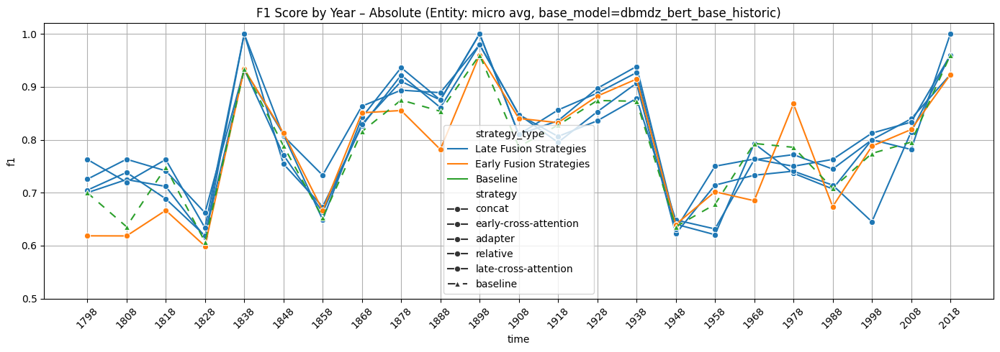

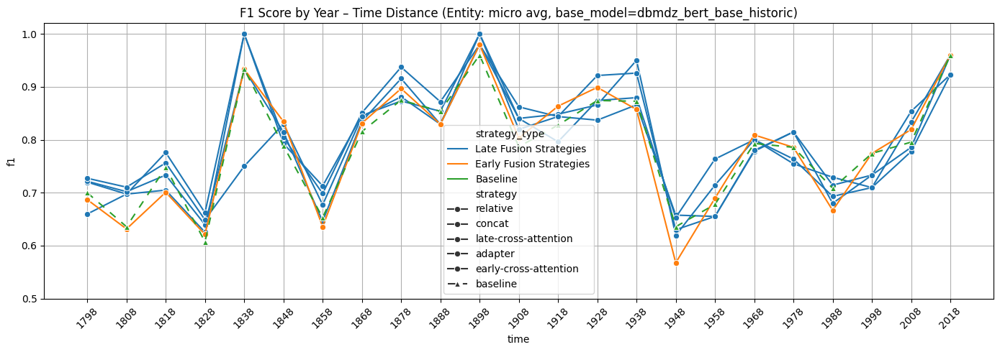

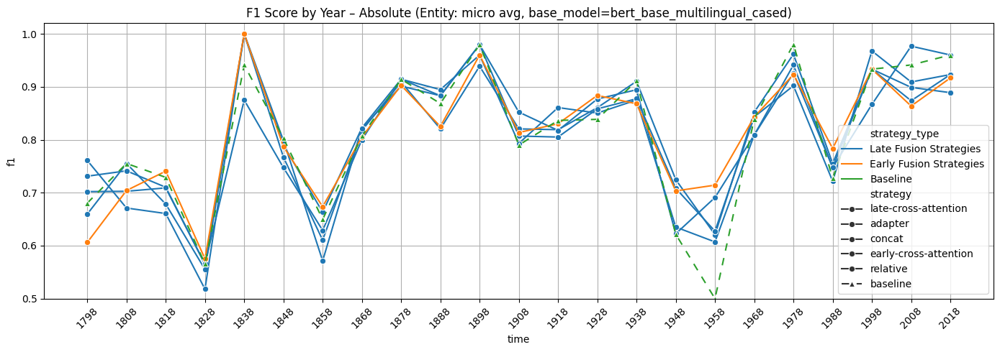

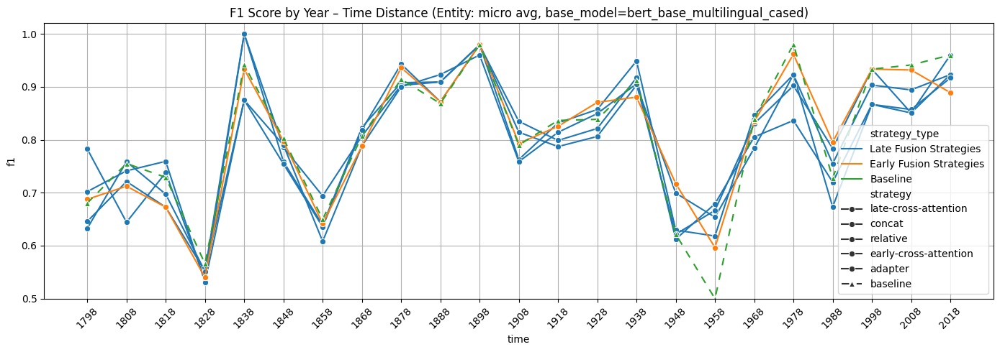

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use proper dash pattern for dashed and solid lines
custom_dashes = {
    model: (5, 5) if model == "baseline" else ""  # Dashed for baseline, solid for others
    for model in results_df_cleaned["strategy"].unique()
}

# Triangle marker for 'baseline', circle for others
custom_markers = {
    model: "^" if model == "baseline" else "o"
    for model in results_df_cleaned["strategy"].unique()
}

for base_model in results_df_cleaned["base_model"].unique():
    for temporal_mode in results_df_cleaned["temporal_mode"].unique():
        if temporal_mode == "No Temporal Info":
            continue  # Skip standalone plotting of the baseline as a separate mode

        # Subset for current temporal mode + baseline
        df = results_df_cleaned[
            (results_df_cleaned["base_model"] == base_model) &
            ((results_df_cleaned["temporal_mode"] == temporal_mode) |
             (results_df_cleaned["temporal_mode"] == "No Temporal Info"))
        ]

        for entity in ["micro avg"]:
            plt.figure(figsize=(14, 5))

            plot_data = df[
                (df["scope"] == "year") &
                (df["entity_type"] == entity)
            ]
            if plot_data.empty:
                continue

            sns.lineplot(
                data=plot_data,
                x="time",
                y="f1",
                hue="strategy_type",
                style="strategy",
                dashes=custom_dashes,
                markers=custom_markers
            )

            # Annotate stats
            stats_filtered = entity_stats_df[
                (entity_stats_df["entity_type"] == entity) &
                (entity_stats_df["split"] == "test") &
                (entity_stats_df["year"].isin(plot_data["time"]))
            ]
            for _, row in stats_filtered.iterrows():
                plt.annotate(
                    f'n={row["count"]}',
                    xy=(row["year"], 0.51),
                    textcoords="offset points",
                    xytext=(0, 5),
                    ha='center', fontsize=8, color='gray'
                )

            plt.title(f"F1 Score by Year – {temporal_mode} (Entity: {entity}, base_model={base_model})")
            plt.xticks(rotation=45)
            plt.ylim(0.5, 1.02)
            plt.grid(True)
            plt.tight_layout()
            plt.show()

In [140]:
results_df.head()

,scope,time,entity_type,precision,recall,f1,run,run_clean,strategy,max_len,base_model,relative_year,temporal_mode,strategy_type
0,year,1798,loc,0.6154,0.8000,0.6957,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
1,year,1798,org,0.5000,1.0000,0.6667,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
2,year,1798,pers,0.7188,0.7419,0.7302,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
3,year,1798,time,0.0000,0.0000,0.0000,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
4,year,1798,micro avg,0.6481,0.7609,0.7000,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies


In [141]:
df = results_df[
    (results_df["base_model"] == "dbmdz_bert_base") &
    (results_df["temporal_mode"] == 'Time Distance')
]
df.strategy.unique()

array([], dtype=object)

In [142]:
df = results_df[results_df["base_model"] == "dbmdz_bert_base"]
df = df[df["temporal_mode"] == 'Time Distance']
df.strategy.unique()

array([], dtype=object)

In [143]:
df.temporal_mode.unique()

array([], dtype=object)

/var/folders/rv/x6hk7f3j7dzb763m4m3kgmb00000gp/T/ipykernel_5917/779461468.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
/var/folders/rv/x6hk7f3j7dzb763m4m3kgmb00000gp/T/ipykernel_5917/779461468.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)


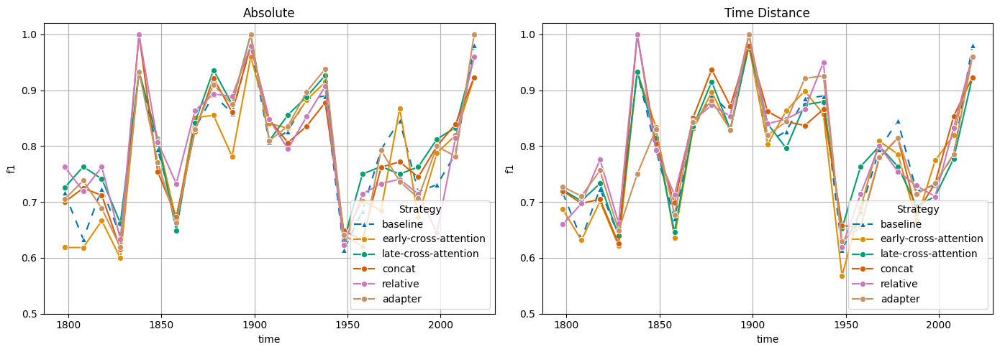

Saved: ../images/yearly_f1_by_strategy_row_dbmdz_bert_base_historic.png


/var/folders/rv/x6hk7f3j7dzb763m4m3kgmb00000gp/T/ipykernel_5917/779461468.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
/var/folders/rv/x6hk7f3j7dzb763m4m3kgmb00000gp/T/ipykernel_5917/779461468.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)


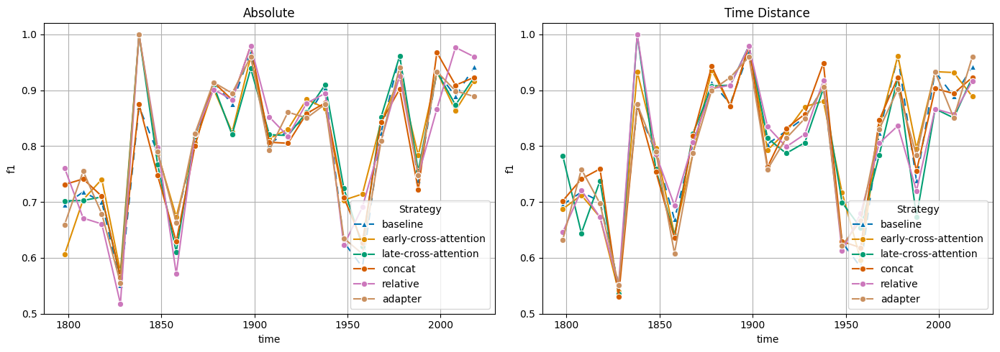

Saved: ../images/yearly_f1_by_strategy_row_bert_base_multilingual_cased.png


In [144]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd
import os
from pandas.api.types import CategoricalDtype

# Set output directory
output_dir = "../images"
os.makedirs(output_dir, exist_ok=True)

# Define and order strategy types
strategy_type_order = ['baseline', 'early-cross-attention', 'late-cross-attention', 'concat', 'relative', 'adapter']
strategy_palette = sns.color_palette("colorblind", n_colors=len(strategy_type_order))
strategy_colors = dict(zip(strategy_type_order, strategy_palette))

# Ensure strategy column is ordered categorically
results_df["strategy"] = results_df["strategy"].astype(
    CategoricalDtype(categories=strategy_type_order, ordered=True)
)

# Custom dashes and markers
custom_dashes = {stype: (5, 5) if stype == "baseline" else "" for stype in strategy_type_order}
custom_markers = {stype: "^" if stype == "baseline" else "o" for stype in strategy_type_order}

# Define plotting tasks: all (base_model, temporal_mode) combinations
plot_tasks = [
    (bm, tm)
    for bm in results_df["base_model"].unique()
    for tm in results_df["temporal_mode"].unique()
    if tm != "No Temporal Info"  # Skip standalone baseline plots
]

# Group into rows of 2
n_cols = 2
task_groups = [plot_tasks[i:i+n_cols] for i in range(0, len(plot_tasks), n_cols)]

# Create figures
for group in task_groups:
    fig, axes = plt.subplots(1, n_cols, figsize=(14, 5), squeeze=False)
    axes = axes[0]  # flatten

    for ax, (base_model, temporal_mode) in zip(axes, group):
        # Include both temporal_mode-specific and baseline data
        df = results_df[
            (results_df["base_model"] == base_model) &
            (
                (results_df["temporal_mode"] == temporal_mode) |
                (results_df["temporal_mode"] == "No Temporal Info")
            )
        ]

        # Ensure all strategies are represented (even with placeholders)
        missing = [stype for stype in strategy_type_order if stype not in df["strategy"].unique()]
        for miss in missing:
            filler = results_df[
                (results_df["strategy"] == miss) &
                (results_df["base_model"] == base_model)
            ]
            if not filler.empty:
                # Pick correct temporal_mode for filler
                if miss == "baseline":
                    filler = filler[filler["temporal_mode"] == "No Temporal Info"]
                else:
                    filler = filler[filler["temporal_mode"] == temporal_mode]
                df = pd.concat([df, filler.iloc[[0]]])

        # Filter and sort for plotting
        plot_data = df[
            (df["scope"] == "year") &
            (df["entity_type"] == "micro avg")
        ].sort_values("strategy")

        if plot_data.empty:
            ax.set_visible(False)
            continue

        plot_data["time"] = plot_data["time"].astype(int)

        # Plot
        sns.lineplot(
            data=plot_data,
            x="time",
            y="f1",
            hue="strategy",
            style="strategy",
            dashes=custom_dashes,
            markers=custom_markers,
            palette=strategy_colors,
            ax=ax
        )

        ax.set_title(f"{temporal_mode}")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        ax.set_ylim(0.5, 1.02)
        ax.grid(True)
        ax.legend(title="Strategy", loc="lower right")

    fig.tight_layout()
    fig_path = os.path.join(output_dir, f"yearly_f1_by_strategy_row_{base_model}.png")
    plt.savefig(fig_path, dpi=300)
    plt.show()
    plt.close()
    print(f"Saved: {fig_path}")

In [145]:
results_df

,scope,time,entity_type,precision,recall,f1,run,run_clean,strategy,max_len,base_model,relative_year,temporal_mode,strategy_type
0,year,1798,loc,0.6154,0.8000,0.69570,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
1,year,1798,org,0.5000,1.0000,0.66670,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
2,year,1798,pers,0.7188,0.7419,0.73020,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
3,year,1798,time,0.0000,0.0000,0.00000,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
4,year,1798,micro avg,0.6481,0.7609,0.70000,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5167,year,1948,time,NaN,NaN,0.55390,None,None,baseline,None,dbmdz_bert_base_historic,None,No Temporal Info,Baseline
5168,decade,1950s,time,NaN,NaN,0.90415,None,None,baseline,None,dbmdz_bert_base_historic,None,No Temporal Info,Baseline
5169,year,1958,time,NaN,NaN,0.90415,None,None,baseline,None,dbmdz_bert_base_historic,None,No Temporal Info,Baseline
5170,decade,1960s,time,NaN,NaN,0.87120,None,None,baseline,None,dbmdz_bert_base_historic,None,No Temporal Info,Baseline


['Late Fusion Strategies', 'Early Fusion Strategies', 'Baseline']
Categories (3, object): ['Baseline' < 'Early Fusion Strategies' < 'Late Fusion Strategies']


/var/folders/rv/x6hk7f3j7dzb763m4m3kgmb00000gp/T/ipykernel_5917/3915432532.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
/var/folders/rv/x6hk7f3j7dzb763m4m3kgmb00000gp/T/ipykernel_5917/3915432532.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)


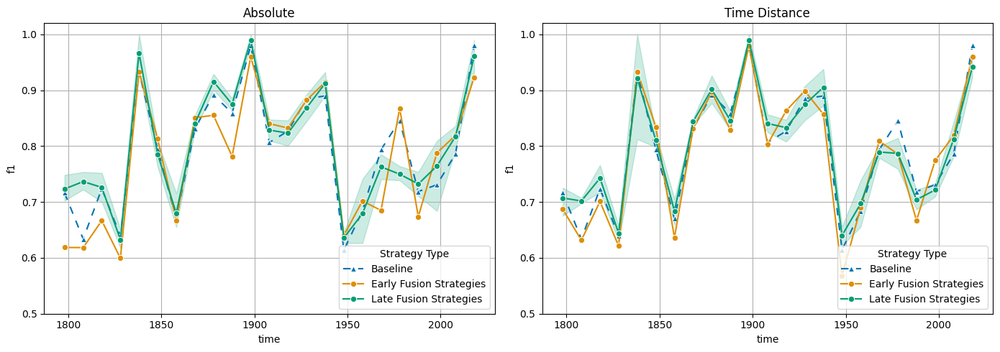

Saved: ../images/yearly_f1_by_strategy_type_row_dbmdz_bert_base_historic.png


/var/folders/rv/x6hk7f3j7dzb763m4m3kgmb00000gp/T/ipykernel_5917/3915432532.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
/var/folders/rv/x6hk7f3j7dzb763m4m3kgmb00000gp/T/ipykernel_5917/3915432532.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)


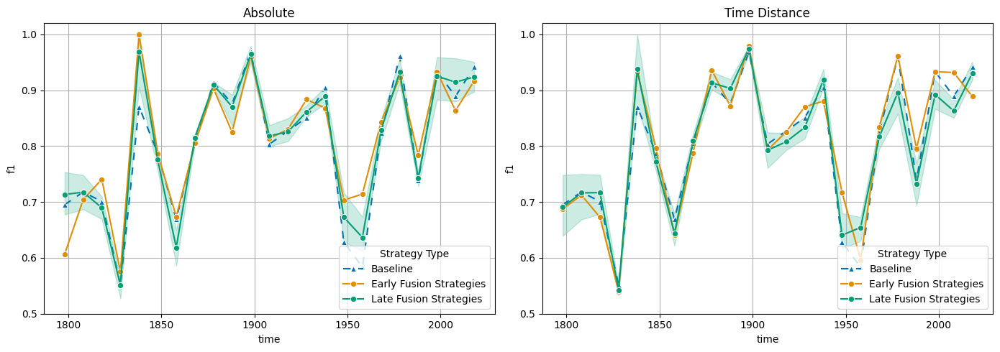

Saved: ../images/yearly_f1_by_strategy_type_row_bert_base_multilingual_cased.png


In [146]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd
import os
from pandas.api.types import CategoricalDtype

# Set output directory
output_dir = "../images"
os.makedirs(output_dir, exist_ok=True)

# Define and order strategy types
strategy_type_order = ["Baseline", "Early Fusion Strategies", "Late Fusion Strategies"]
strategy_palette = sns.color_palette("colorblind", n_colors=len(strategy_type_order))
strategy_colors = dict(zip(strategy_type_order, strategy_palette))

results_df["strategy_type"] = results_df["strategy_type"].astype(
    CategoricalDtype(categories=strategy_type_order, ordered=True)
)

print(results_df["strategy_type"].unique())

custom_dashes = {stype: (5, 5) if stype == "Baseline" else "" for stype in strategy_type_order}
custom_markers = {stype: "^" if stype == "Baseline" else "o" for stype in strategy_type_order}

# Plot tasks: (base_model, temporal_mode) pairs, excluding 'No Temporal Info' as a standalone
plot_tasks = [
    (bm, tm)
    for bm in results_df["base_model"].unique()
    for tm in results_df["temporal_mode"].unique()
    if tm != "No Temporal Info"
]

# Group tasks into rows of 2
n_cols = 2
task_groups = [plot_tasks[i:i+n_cols] for i in range(0, len(plot_tasks), n_cols)]

# Create figures
for group in task_groups:
    fig, axes = plt.subplots(1, n_cols, figsize=(14, 5), squeeze=False)
    axes = axes[0]  # flatten

    for ax, (base_model, temporal_mode) in zip(axes, group):
        # Include baseline + current temporal_mode
        df = results_df[
            (results_df["base_model"] == base_model) &
            (
                (results_df["temporal_mode"] == temporal_mode) |
                (results_df["temporal_mode"] == "No Temporal Info")
            )
        ]

        # Ensure all strategy types are included
        missing = [stype for stype in strategy_type_order if stype not in df["strategy_type"].unique()]
        for miss in missing:
            filler = results_df[
                (results_df["strategy_type"] == miss) &
                (results_df["base_model"] == base_model)
            ]
            if not filler.empty:
                # Pull the correct temporal_mode version
                if miss == "Baseline":
                    filler = filler[filler["temporal_mode"] == "No Temporal Info"]
                else:
                    filler = filler[filler["temporal_mode"] == temporal_mode]
                df = pd.concat([df, filler.iloc[[0]]])

        plot_data = df[
            (df["scope"] == "year") &
            (df["entity_type"] == "micro avg")
        ].sort_values("strategy_type")

        if plot_data.empty:
            ax.set_visible(False)
            continue

        plot_data["time"] = plot_data["time"].astype(int)
        sns.lineplot(
            data=plot_data,
            x="time",
            y="f1",
            hue="strategy_type",
            style="strategy_type",
            dashes=custom_dashes,
            markers=custom_markers,
            palette=strategy_colors,
            ax=ax
        )

        ax.set_title(f"{temporal_mode}")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        ax.set_ylim(0.5, 1.02)
        ax.grid(True)
        ax.legend(title="Strategy Type", loc="lower right")

    fig.tight_layout()
    fig_path = os.path.join(output_dir, f"yearly_f1_by_strategy_type_row_{base_model}.png")
    plt.savefig(fig_path, dpi=300)
    plt.show()
    plt.close()
    print(f"Saved: {fig_path}")

In [147]:
results_df.strategy.unique()


['concat', 'relative', 'late-cross-attention', 'adapter', 'early-cross-attention', 'baseline']
Categories (6, object): ['baseline' < 'early-cross-attention' < 'late-cross-attention' < 'concat' < 'relative' < 'adapter']

/var/folders/rv/x6hk7f3j7dzb763m4m3kgmb00000gp/T/ipykernel_5917/3968935375.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["strategy", "temporal_mode"])
/var/folders/rv/x6hk7f3j7dzb763m4m3kgmb00000gp/T/ipykernel_5917/3968935375.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pivot, x="delta", y="strategy", palette="coolwarm")


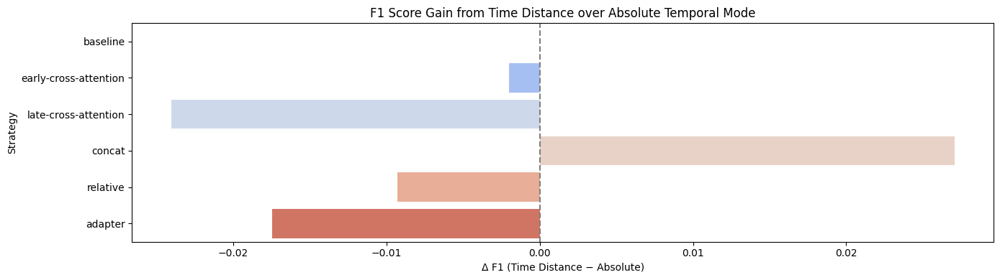

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your results
df = results_df.copy()

# Group to get mean F1 per strategy and temporal mode
agg = (
    df.groupby(["strategy", "temporal_mode"])
    .agg(mean_f1=("f1", "mean"))
    .reset_index()
)

# Pivot to compute deltas
pivot = agg.pivot(index="strategy", columns="temporal_mode", values="mean_f1")
pivot["delta"] = pivot["Time Distance"] - pivot["Absolute"]
pivot = pivot.reset_index()

# Plot
plt.figure(figsize=(14, 4))
sns.barplot(data=pivot, x="delta", y="strategy", palette="coolwarm")
plt.axvline(0, linestyle="--", color="gray")
plt.xlabel("Δ F1 (Time Distance − Absolute)")
plt.ylabel("Strategy")
plt.title("F1 Score Gain from Time Distance over Absolute Temporal Mode")
plt.tight_layout()
plt.savefig("../images/delta_f1_by_temporal_mode.png", dpi=300)
plt.show()

/var/folders/rv/x6hk7f3j7dzb763m4m3kgmb00000gp/T/ipykernel_5917/909391736.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["strategy", "time", "entity_type", "max_len", "relative_year", "scope"])["f1"]


      strategy   time entity_type max_len  relative_year   scope   f1_std
4     baseline  1790s   micro avg     512          False  decade      NaN
6     baseline  1790s   micro avg     512           True  decade      NaN
28    baseline   1798   micro avg     512          False  decade      NaN
30    baseline   1798   micro avg     512           True  decade      NaN
52    baseline  1800s   micro avg     512          False  decade      NaN
...        ...    ...         ...     ...            ...     ...      ...
6558   adapter   2008   micro avg     512           True  decade      NaN
6580   adapter  2010s   micro avg     512          False  decade  0.07856
6582   adapter  2010s   micro avg     512           True  decade  0.00000
6604   adapter   2018   micro avg     512          False  decade      NaN
6606   adapter   2018   micro avg     512           True  decade      NaN

[552 rows x 7 columns]


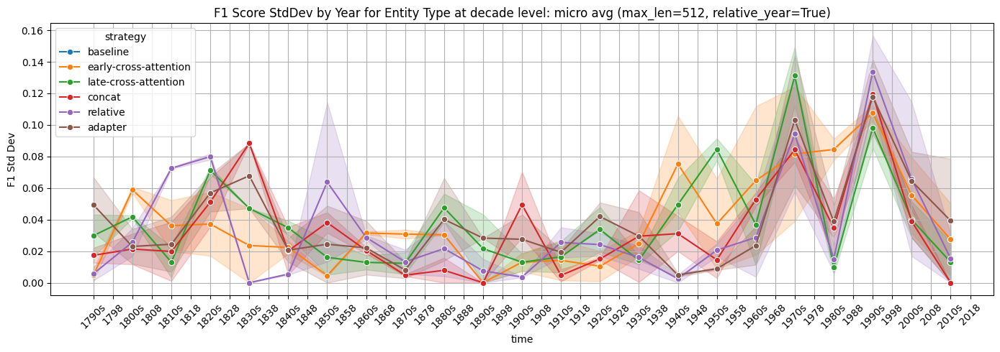

      strategy   time entity_type max_len  relative_year scope    f1_std
5     baseline  1790s   micro avg     512          False  year       NaN
7     baseline  1790s   micro avg     512           True  year       NaN
29    baseline   1798   micro avg     512          False  year       NaN
31    baseline   1798   micro avg     512           True  year       NaN
53    baseline  1800s   micro avg     512          False  year       NaN
...        ...    ...         ...     ...            ...   ...       ...
6559   adapter   2008   micro avg     512           True  year  0.045891
6581   adapter  2010s   micro avg     512          False  year       NaN
6583   adapter  2010s   micro avg     512           True  year       NaN
6605   adapter   2018   micro avg     512          False  year  0.078560
6607   adapter   2018   micro avg     512           True  year  0.000000

[552 rows x 7 columns]


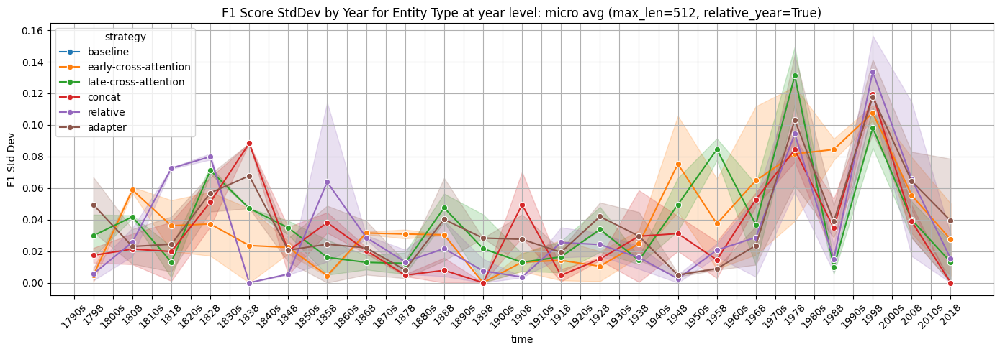

In [149]:
# Compute std per model across time
std_df = (
    results_df
    .groupby(["strategy", "time", "entity_type", "max_len", "relative_year", "scope"])["f1"]
    .std()
    .reset_index(name="f1_std")
)
# print(std_df)
# Plot per model

for scope in std_df["scope"].unique():
    entity = "micro avg"
    df_std = std_df[
        (std_df["scope"] == scope) &
        (std_df["entity_type"] == entity) #&
        # (std_df["max_len"] == 512) &
        # (std_df["relative_year"] == True)
    ]
    print(df_std)
    plt.figure(figsize=(14, 5))
    sns.lineplot(
        data=df_std,
        x="time", y="f1_std",
        hue="strategy",
        marker="o"
    )
    plt.title(f"F1 Score StdDev by Year for Entity Type at {scope} level: {entity} (max_len=512, relative_year=True)")
    plt.ylabel("F1 Std Dev")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [150]:
results_df.head()

,scope,time,entity_type,precision,recall,f1,run,run_clean,strategy,max_len,base_model,relative_year,temporal_mode,strategy_type
0,year,1798,loc,0.6154,0.8000,0.6957,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
1,year,1798,org,0.5000,1.0000,0.6667,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
2,year,1798,pers,0.7188,0.7419,0.7302,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
3,year,1798,time,0.0000,0.0000,0.0000,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
4,year,1798,micro avg,0.6481,0.7609,0.7000,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies



🔍 Plot 1: Early vs. Late vs. Baseline (relative_year = True)

📍 Title: F1 Score by Year for Entity Type: micro avg (max_len=512) (relative_year=True)

Summary:
	•	Late fusion strategies (orange) perform consistently better than the baseline (blue).
	•	Early fusion (green) is quite close to the baseline and even underperforms at times (e.g., 1858, 1948, 1958).
	•	Late fusion offers more stability across time and consistently boosts performance.
	•	There’s a visible dip in all strategies around 1828, 1858, 1948, and 1958 — possibly due to OCR noise or reduced training signal.

Next steps:
	1.	✅ Quantify average delta F1 per strategy over time — how much better is late fusion than baseline?
	2.	🧪 Run significance tests (e.g., paired t-test) between strategies over years to see if improvements are meaningful.
	3.	📊 Error analysis around dip years (1828, 1858, 1948, 1958) to understand why all models struggle there.

⸻

🔍 Plot 2: All models (relative_year = False)

📍 Title: F1 Score by Year for Entity Type: micro avg (max_len=512) (relative_year=False)

Summary:
	•	All temporal fusion models perform better than baseline, especially:
	•	relative, late-cross-attention, and adapter.
	•	early-cross-attention starts weaker but catches up over time.
	•	Some strong spikes in the 1830s and again in 2018 — investigate these further.

Next steps:
	1.	✅ Group models by fusion type (early, late, FiLM, etc.) and compare performance more structurally.
	2.	🗃️ Cluster time periods where models differ most — you might find patterns that correlate with digitization or genre shifts.
	3.	📌 Compare performance across entity types, not just micro average.

⸻

🔍 Plot 3: Early vs. Late vs. Baseline (relative_year = False)

📍 Title: F1 Score by Year for Entity Type: micro avg (max_len=512) (relative_year=False)

Summary:
	•	Here, late fusion (blue) clearly outperforms both early fusion (green) and baseline (orange) across most years.
	•	Early fusion does well post-1860 but is unstable.
	•	The late fusion line has narrow confidence intervals, meaning it’s more consistent.

Next steps:
	1.	📈 Plot std deviation over time per strategy to highlight robustness.
	2.	📉 Highlight low-confidence years — do they correlate with low entity counts? (tie in entity_stats_df)
	3.	🔁 Compare this with the relative-year=True version (Plot 1) — does including relative time help or hurt?

⸻

🚀 Final Suggested Analyses:

Goal	Suggested Analysis
Understand temporal fusion effects	Aggregate F1 gains per fusion type (early, late, FiLM, adapter, etc.)
Model robustness	Plot variance and confidence intervals per strategy
Identify “hard years”	Cross-check F1 dips with OCR errors, entity sparsity, or text length
Understand role of relative time	Directly compare models trained with and without relative_year
Entity-level performance	Repeat the analysis per entity type instead of micro avg
Significance	Run significance testing across strategies and years

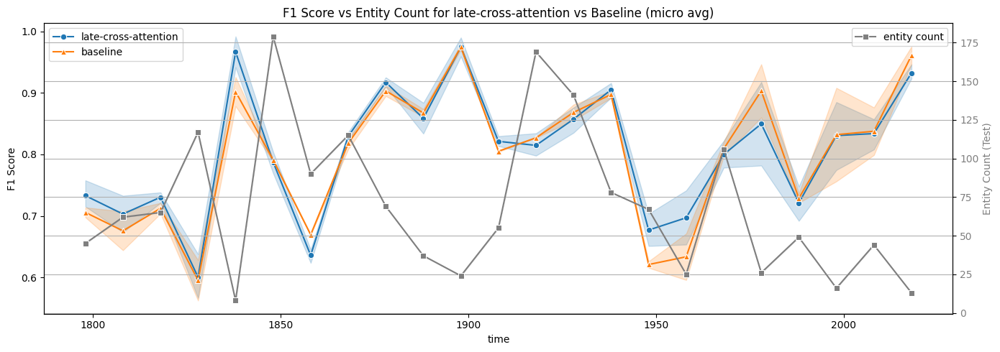

In [151]:
# Settings
entity = "micro avg"
model_of_interest = "late-cross-attention"
baseline_model = "baseline"
relative_year = True
max_len = 512
scope = "year"

# Get F1 for model of interest
f1_df = results_df[
    (results_df["strategy"] == model_of_interest) &
    (results_df["entity_type"] == entity) & 
    (results_df["scope"] == scope)
][["time", "f1"]].rename(columns={"f1": "f1_model"})
f1_df["time"] = f1_df["time"].astype(int)

# Get baseline F1
baseline_df = results_df[
    (results_df["strategy"] == baseline_model) &
    (results_df["entity_type"] == entity) & 
    (results_df["scope"] == scope)
][["time", "f1"]].rename(columns={"f1": "f1_baseline"})
baseline_df["time"] = baseline_df["time"].astype(int)

# Get counts
count_df = entity_stats_df[
    (entity_stats_df["entity_type"] == entity)
][["year", "count"]].rename(columns={"year": "time"})
count_df["time"] = count_df["time"].astype(int)

# Merge everything
merged = f1_df.merge(baseline_df, on="time", how="inner").merge(count_df, on="time", how="inner")

# Plot
fig, ax1 = plt.subplots(figsize=(14, 5))

sns.lineplot(data=merged, x="time", y="f1_model", marker="o", ax=ax1, label=model_of_interest, color="tab:blue")
sns.lineplot(data=merged, x="time", y="f1_baseline", marker="^", ax=ax1, label="baseline", color="tab:orange")
ax1.set_ylabel("F1 Score", color="black")
ax1.tick_params(axis="y", labelcolor="black")
ax1.set_title(f"F1 Score vs Entity Count for {model_of_interest} vs Baseline ({entity})")

# Second y-axis for entity count
ax2 = ax1.twinx()
sns.lineplot(data=merged, x="time", y="count", marker="s", ax=ax2, label="entity count", color="tab:gray")
ax2.set_ylabel("Entity Count (Test)", color="tab:gray")
ax2.tick_params(axis="y", labelcolor="tab:gray")

# Legends and layout
ax1.legend(loc="upper left")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [152]:
results_df

,scope,time,entity_type,precision,recall,f1,run,run_clean,strategy,max_len,base_model,relative_year,temporal_mode,strategy_type
0,year,1798,loc,0.6154,0.8000,0.69570,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
1,year,1798,org,0.5000,1.0000,0.66670,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
2,year,1798,pers,0.7188,0.7419,0.73020,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
3,year,1798,time,0.0000,0.0000,0.00000,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
4,year,1798,micro avg,0.6481,0.7609,0.70000,model_dbmdz_bert_base_historic_multilingual_ca...,time-swiglu.concat.False-bert-base-512,concat,512,dbmdz_bert_base_historic,False,Absolute,Late Fusion Strategies
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5167,year,1948,time,NaN,NaN,0.55390,None,None,baseline,None,dbmdz_bert_base_historic,None,No Temporal Info,Baseline
5168,decade,1950s,time,NaN,NaN,0.90415,None,None,baseline,None,dbmdz_bert_base_historic,None,No Temporal Info,Baseline
5169,year,1958,time,NaN,NaN,0.90415,None,None,baseline,None,dbmdz_bert_base_historic,None,No Temporal Info,Baseline
5170,decade,1960s,time,NaN,NaN,0.87120,None,None,baseline,None,dbmdz_bert_base_historic,None,No Temporal Info,Baseline


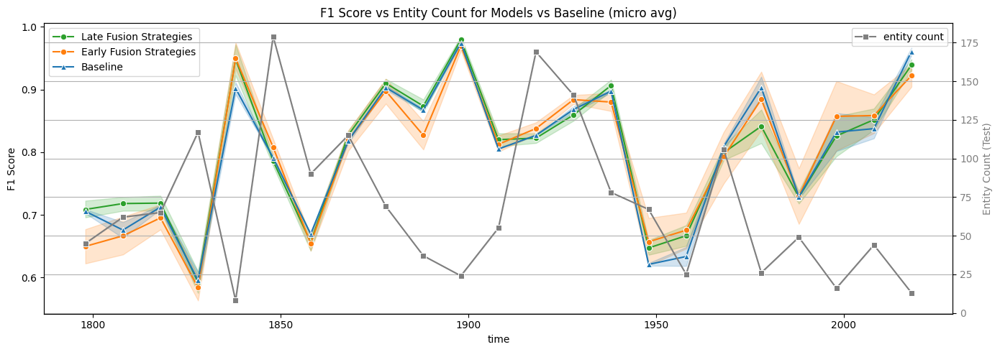

In [153]:
# Settings
entity = "micro avg"
model_of_interest = ["Late Fusion Strategies", "Early Fusion Strategies"]
baseline_model = "Baseline"
scope = "year"

# Get F1 for models of interest
f1_df = results_df[
    (results_df["strategy_type"].isin(model_of_interest)) &
    (results_df["entity_type"] == entity) &
    (results_df["scope"] == scope)
][["time", "f1", "strategy_type"]]
f1_df["time"] = f1_df["time"].astype(int)

# Get baseline F1
baseline_df = results_df[
    (results_df["strategy_type"] == baseline_model) &
    (results_df["entity_type"] == entity) &
    (results_df["scope"] == scope)
][["time", "f1"]].rename(columns={"f1": "f1_baseline"})
baseline_df["time"] = baseline_df["time"].astype(int)

# Get entity counts
count_df = entity_stats_df[
    (entity_stats_df["entity_type"] == entity)
][["year", "count"]].rename(columns={"year": "time"})
count_df["time"] = count_df["time"].astype(int)

# Merge F1 with baseline
merged = f1_df.merge(baseline_df, on="time", how="inner").merge(count_df, on="time", how="inner")

# Plotting
fig, ax1 = plt.subplots(figsize=(14, 5))

# Define custom color mapping
color_map = {
    "Late Fusion Strategies": "tab:green",
    "Early Fusion Strategies": "tab:orange",
    "Baseline": "tab:blue"
}

# Plot each model of interest with its specific color
for strategy in model_of_interest:
    subset = merged[merged["strategy_type"] == strategy]
    sns.lineplot(data=subset, x="time", y="f1", marker="o", ax=ax1, label=strategy, color=color_map[strategy])

# Plot baseline with its specific color
sns.lineplot(data=merged, x="time", y="f1_baseline", marker="^", ax=ax1, label=baseline_model, color=color_map[baseline_model])

# Left Y-axis: F1 scores
ax1.set_ylabel("F1 Score", color="black")
ax1.tick_params(axis="y", labelcolor="black")
ax1.set_title(f"F1 Score vs Entity Count for Models vs Baseline ({entity})")

# Right Y-axis: entity count
ax2 = ax1.twinx()
sns.lineplot(data=merged, x="time", y="count", marker="s", ax=ax2, label="entity count", color="tab:gray")
ax2.set_ylabel("Entity Count (Test)", color="tab:gray")
ax2.tick_params(axis="y", labelcolor="tab:gray")

# X-axis and layout
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Save figure
filename = f"../images/f1_vs_entity_count_{'_'.join([s.replace(' ', '_').lower() for s in model_of_interest])}_vs_baseline_{entity.replace(' ', '_').lower()}.png"
plt.savefig(filename, dpi=300)

# Show plot
plt.show()

In [154]:
merged

,time,f1,strategy_type,f1_baseline,count
0,1798,0.7000,Late Fusion Strategies,0.69505,45
1,1798,0.7000,Late Fusion Strategies,0.71635,45
2,1808,0.7248,Late Fusion Strategies,0.71790,62
3,1808,0.7248,Late Fusion Strategies,0.63370,62
4,1818,0.7119,Late Fusion Strategies,0.70085,65
...,...,...,...,...,...
915,1998,0.9333,Late Fusion Strategies,0.73085,16
916,2008,0.8506,Late Fusion Strategies,0.88920,44
917,2008,0.8506,Late Fusion Strategies,0.78600,44
918,2018,0.9600,Late Fusion Strategies,0.94155,13


In [155]:
results_df.entity_type.unique()

array(['loc', 'org', 'pers', 'time', 'micro avg', 'prod'], dtype=object)

In [156]:
merged

,time,f1,strategy_type,f1_baseline,count
0,1798,0.7000,Late Fusion Strategies,0.69505,45
1,1798,0.7000,Late Fusion Strategies,0.71635,45
2,1808,0.7248,Late Fusion Strategies,0.71790,62
3,1808,0.7248,Late Fusion Strategies,0.63370,62
4,1818,0.7119,Late Fusion Strategies,0.70085,65
...,...,...,...,...,...
915,1998,0.9333,Late Fusion Strategies,0.73085,16
916,2008,0.8506,Late Fusion Strategies,0.88920,44
917,2008,0.8506,Late Fusion Strategies,0.78600,44
918,2018,0.9600,Late Fusion Strategies,0.94155,13


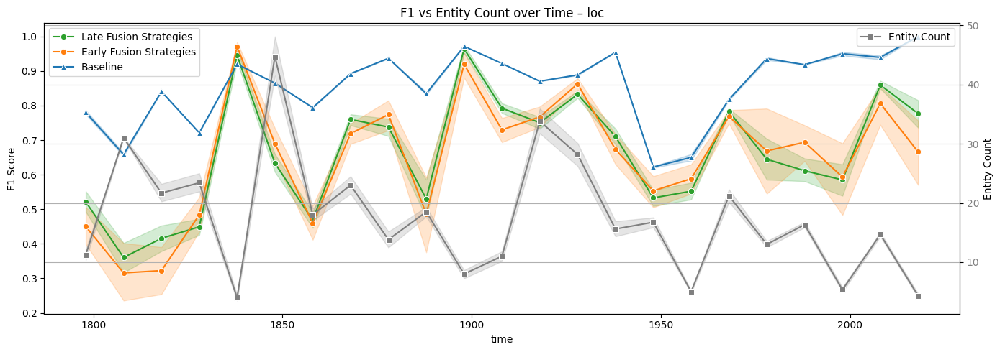

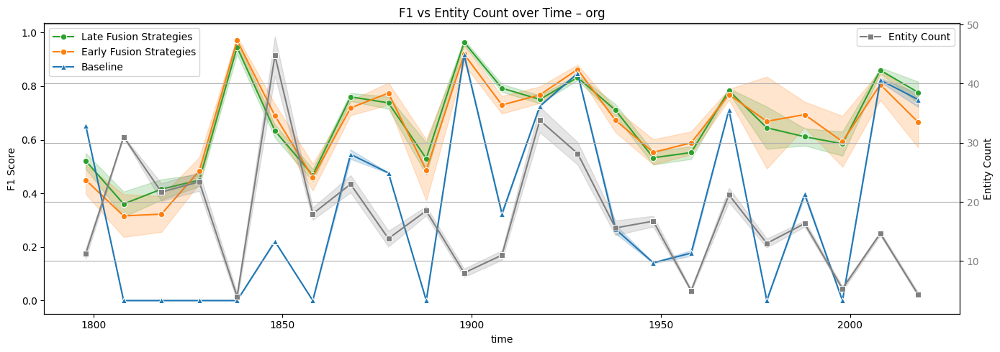

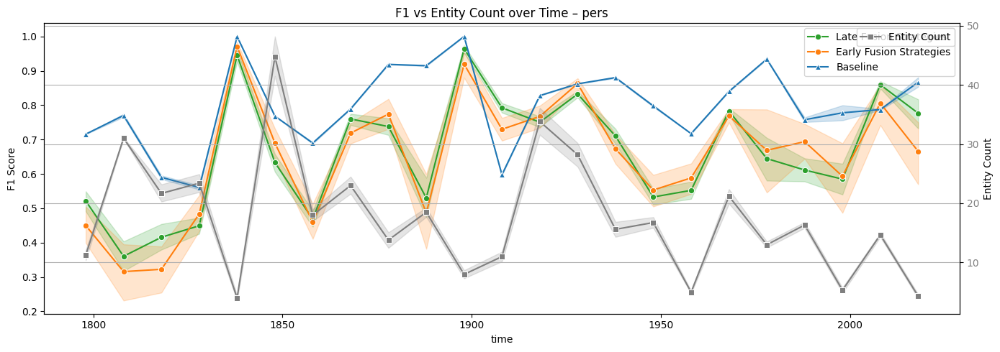

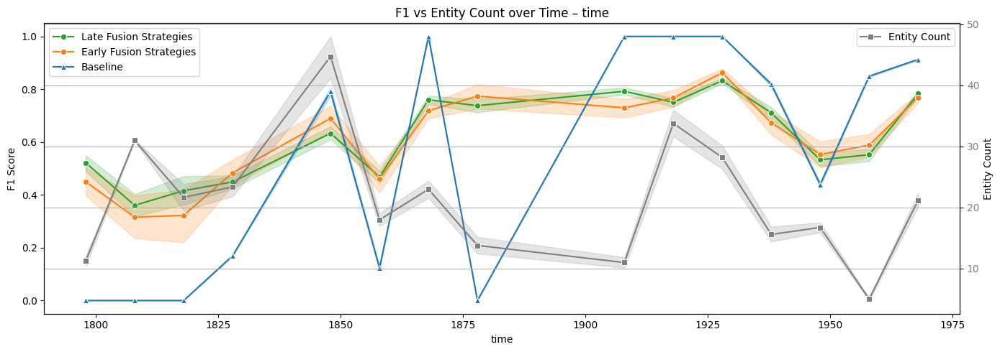

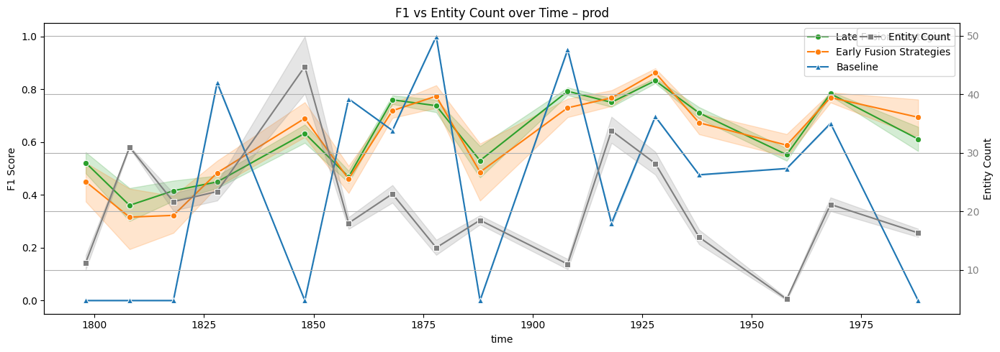

In [157]:
# Settings
entity = ['loc', 'org', 'pers', 'time', 'prod']
model_of_interest = ["Late Fusion Strategies", "Early Fusion Strategies"]
baseline_model = "Baseline"
scope = "year"

# Get F1 for models of interest
f1_df = results_df[
    (results_df["strategy_type"].isin(model_of_interest)) &
    (results_df["entity_type"].isin(entity)) &
    (results_df["scope"] == scope)
][["time", "f1", "strategy_type"]]
f1_df["time"] = f1_df["time"].astype(int)

# Get baseline F1
baseline_df = results_df[
    (results_df["strategy_type"] == baseline_model) &
    (results_df["entity_type"].isin(entity)) &
    (results_df["scope"] == scope)
][["time", "f1", "entity_type"]].rename(columns={"f1": "f1_baseline"})
baseline_df["time"] = baseline_df["time"].astype(int)

# Get entity counts
count_df = entity_stats_df[
    (entity_stats_df["entity_type"].isin(entity))
][["year", "count"]].rename(columns={"year": "time"})
count_df["time"] = count_df["time"].astype(int)

# Merge F1 with baseline
merged = f1_df.merge(baseline_df, on="time", how="inner").merge(count_df, on="time", how="inner")

for etype in merged["entity_type"].unique():
    fig, ax1 = plt.subplots(figsize=(14, 5))
    data = merged[merged["entity_type"] == etype]

    # F1 score (left axis)
    for strategy in model_of_interest:
        subset = data[data["strategy_type"] == strategy]
        sns.lineplot(data=subset, x="time", y="f1", marker="o", ax=ax1, label=strategy, color=color_map[strategy])

    sns.lineplot(data=data, x="time", y="f1_baseline", marker="^", ax=ax1, label=baseline_model, color=color_map[baseline_model])
    ax1.set_ylabel("F1 Score")
    ax1.tick_params(axis='y', labelcolor="black")

    # Entity count (right axis)
    ax2 = ax1.twinx()
    sns.lineplot(data=data, x="time", y="count", marker="s", ax=ax2, label="Entity Count", color="tab:gray")
    ax2.set_ylabel("Entity Count")
    ax2.tick_params(axis='y', labelcolor="gray")

    ax1.set_title(f"F1 vs Entity Count over Time – {etype}")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

/var/folders/rv/x6hk7f3j7dzb763m4m3kgmb00000gp/T/ipykernel_5917/186098161.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.groupby(["strategy_type", "entity_type"])


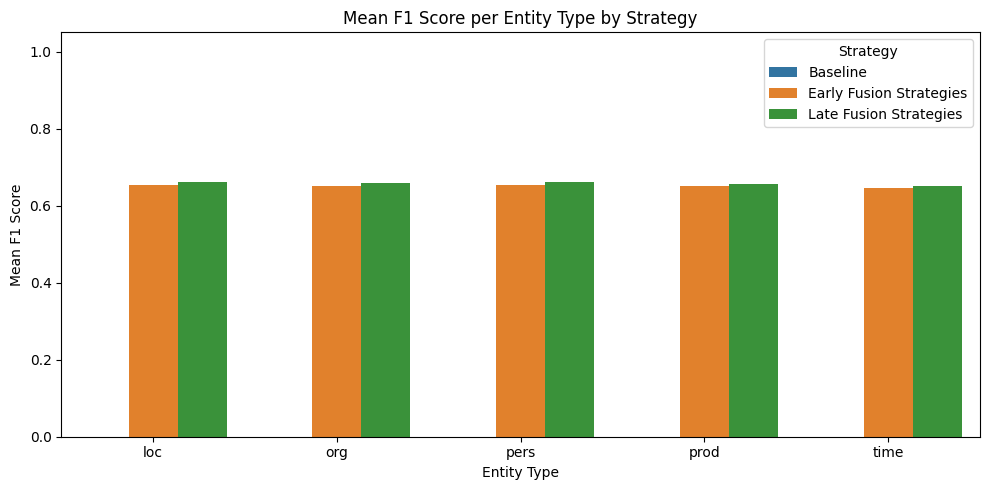

In [158]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group by strategy and entity type
summary = (
    merged.groupby(["strategy_type", "entity_type"])
    .agg(mean_f1=("f1", "mean"))
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(
    data=summary,
    x="entity_type",
    y="mean_f1",
    hue="strategy_type",
    palette=color_map
)

plt.title("Mean F1 Score per Entity Type by Strategy")
plt.ylabel("Mean F1 Score")
plt.xlabel("Entity Type")
plt.ylim(0, 1.05)
plt.legend(title="Strategy")
plt.tight_layout()
plt.savefig("mean_f1_per_entity_type_by_strategy.png", dpi=300)
plt.show()

In [159]:
merged

,time,f1,strategy_type,f1_baseline,entity_type,count
0,1798,0.6957,Late Fusion Strategies,0.70175,loc,10
1,1798,0.6957,Late Fusion Strategies,0.70175,loc,4
2,1798,0.6957,Late Fusion Strategies,0.70175,loc,30
3,1798,0.6957,Late Fusion Strategies,0.70175,loc,1
4,1798,0.6957,Late Fusion Strategies,0.63335,org,10
...,...,...,...,...,...,...
70146,2018,0.8000,Late Fusion Strategies,0.50000,org,1
70147,2018,0.8000,Late Fusion Strategies,0.50000,org,3
70148,2018,0.8000,Late Fusion Strategies,1.00000,pers,9
70149,2018,0.8000,Late Fusion Strategies,1.00000,pers,1


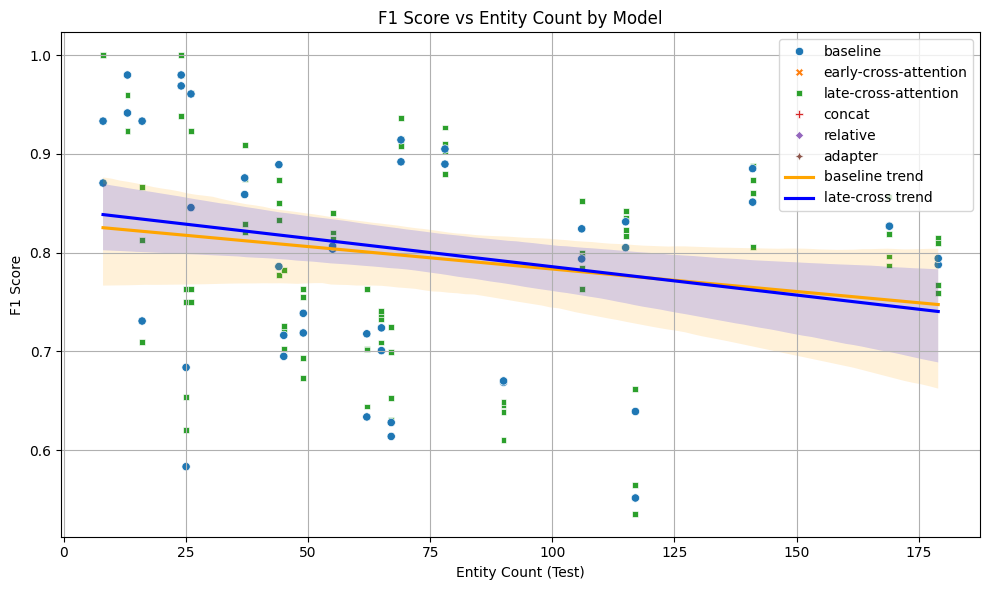

In [160]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Prepare data for both models
entity = "micro avg"
relative_year = True
max_len = 512
scope = "year"

models_to_compare = ["baseline", "late-cross-attention"]
plot_df = results_df[
    (results_df["entity_type"] == entity) &
    (results_df["scope"] == scope) &
    (results_df["strategy"].isin(models_to_compare))
].copy()

# Merge with entity counts
entity_counts = entity_stats_df[
    entity_stats_df["entity_type"] == entity
][["year", "count"]].rename(columns={"year": "time"})
entity_counts["time"] = entity_counts["time"].astype(int)

plot_df["time"] = plot_df["time"].astype(int)
plot_df = plot_df.merge(entity_counts, on="time", how="left")

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x="count", y="f1", hue="strategy", style="strategy")
sns.regplot(data=plot_df[plot_df["strategy"] == "baseline"], x="count", y="f1", scatter=False, color="orange", label="baseline trend")
sns.regplot(data=plot_df[plot_df["strategy"] == "late-cross-attention"], x="count", y="f1", scatter=False, color="blue", label="late-cross trend")

# Optional: Pearson r per model
for model in models_to_compare:
    sub = plot_df[plot_df["strategy"] == model]
    r, p = stats.pearsonr(sub["count"], sub["f1"])
    x_pos = sub["count"].max() * 0.6
    y_pos = 0.2 if model == "baseline" else 0.1
    plt.annotate(f"{model}\nPearson r={r:.2f}, p={p:.3f}", xy=(x_pos, y_pos), fontsize=9, color="black")

plt.title("F1 Score vs Entity Count by Model")
plt.xlabel("Entity Count (Test)")
plt.ylabel("F1 Score")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

/var/folders/rv/x6hk7f3j7dzb763m4m3kgmb00000gp/T/ipykernel_5917/3647767833.py:23: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_rank.pivot_table(index="strategy", columns="time", values="f1", aggfunc="mean")


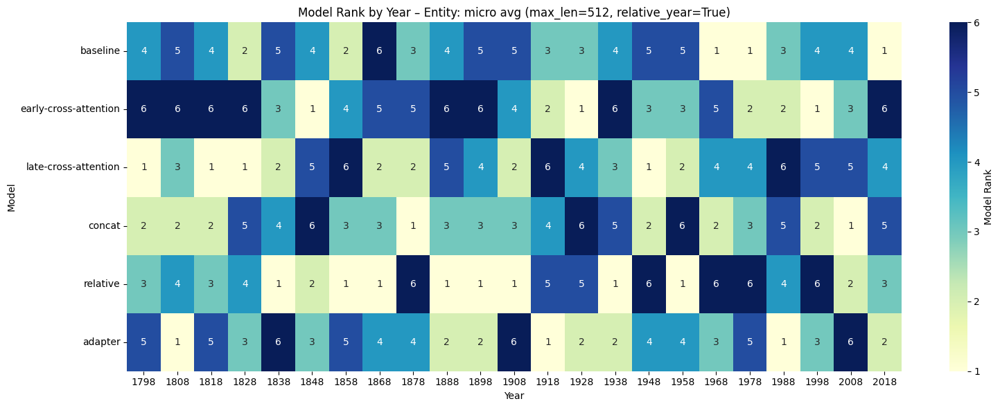

In [161]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Filter for micro avg (or change to desired entity_type)
entity = "micro avg"
max_len = 512
relative_year = True
scope = "year"

df_rank = results_df[
    (results_df["entity_type"] == entity) &
    # (results_df["max_len"] == max_len) &
    # (results_df["relative_year"] == relative_year) &
    (results_df["scope"] == scope)
][["strategy", "time", "f1"]]

# Ensure proper type
df_rank["time"] = df_rank["time"].astype(int)

# Pivot and rank
rank_matrix = (
    df_rank.pivot_table(index="strategy", columns="time", values="f1", aggfunc="mean")
    .rank(ascending=False)  # Lower rank = better model
)

# Plot heatmap
plt.figure(figsize=(16, 6))
sns.heatmap(rank_matrix, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={"label": "Model Rank"})
plt.title(f"Model Rank by Year – Entity: {entity} (max_len={max_len}, relative_year={relative_year})")
plt.xlabel("Year")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

/var/folders/rv/x6hk7f3j7dzb763m4m3kgmb00000gp/T/ipykernel_5917/3757766922.py:37: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_rank.pivot_table(index="strategy", columns="time", values="f1", aggfunc="mean")


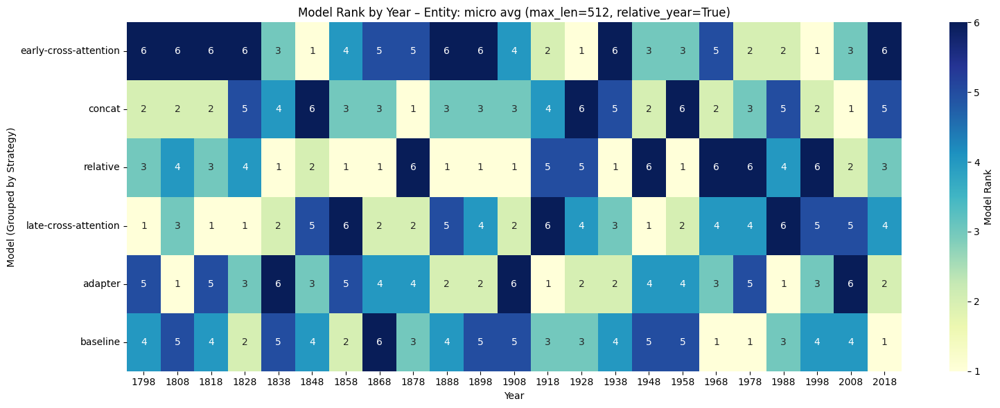

In [162]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define strategy grouping
strategy_order = {
    "early-cross-attention": "early",
    "late-cross-attention": "late",
    "relative": "late",
    "adapter": "late",
    "concat": "late",
    "film": "late",
    "baseline": "baseline"
}

# Optional: define display order manually (early → late → baseline)
model_sort_order = sorted(
    df_rank["strategy"].unique(),
    key=lambda m: {"early": 0, "late": 1, "baseline": 2}[strategy_order.get(m, "late")]
)

# Filter and prepare data
entity = "micro avg"
max_len = 512
relative_year = True
scope = "year"

df_rank = results_df[
    (results_df["entity_type"] == entity) &
    (results_df["scope"] == scope)
][["strategy", "time", "f1"]].copy()

df_rank["time"] = df_rank["time"].astype(int)

# Pivot and rank
rank_matrix = (
    df_rank.pivot_table(index="strategy", columns="time", values="f1", aggfunc="mean")
    .rank(ascending=False)
)

# Reorder model index
rank_matrix = rank_matrix.loc[model_sort_order]

# Plot
plt.figure(figsize=(16, 6))
sns.heatmap(rank_matrix, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={"label": "Model Rank"})
plt.title(f"Model Rank by Year – Entity: {entity} (max_len={max_len}, relative_year={relative_year})")
plt.xlabel("Year")
plt.ylabel("Model (Grouped by Strategy)")
plt.tight_layout()
plt.show()



🔍 Heatmap Interpretation

🟨 Color
	•	Lighter color = better rank (1 = best)
	•	Darker color = worse rank (6 = worst)

⸻

🥇 Consistently Top Performers

🟦 late-cross-attention
	•	Ranks 1–2 very often: e.g., 1798, 1818, 1868, 1938, 1948, 1958, 1968.
	•	Rarely below rank 4.
	•	Most stable high-ranker → strong late fusion method.

🟦 relative
	•	Ranks 1 frequently (1838–1868, 1948, 1958, 2008), though some 6s (1878, 1968).
	•	A bit volatile but generally performs strong in many low-resource years.

⸻

⚠️ Inconsistent Models

🟪 adapter
	•	Highly volatile: rank 1 in 1808, 1918, but 5–6 in other years.
	•	Indicates sensitivity to temporal shifts or lack of robustness.

🟩 concat
	•	Decent middle performer: often ranks 2–4, not leading, not worst.

⸻

🟥 Weakest Overall

🟥 early-cross-attention
	•	Very frequent ranks 5–6 (worst) → especially poor in early and mid-20th century.
	•	Only rare 1s (e.g., 1938, 1948), but overall underperforms.

⸻

🟧 Baseline
	•	Surprisingly strong in later years: top-1 in 1828, 2008, 2018.
	•	However, fluctuates widely: ranked 6 in 1808, 1928.
	•	This suggests baseline is sometimes sufficient, particularly when data is cleaner or temporally stable.

⸻

📊 Trends Over Time

Period	Trend
1798–1850	Late-cross-attention & relative start to shine
1860s–1890s	Models fluctuate more, possibly due to OCR or low data quality
1900–1960	Late fusion methods dominate, early fusion struggles
2000–2018	Baseline makes a comeback; fusion methods still helpful


⸻

🧠 Summary

Strategy Type	Verdict
Late fusion	✅ Most consistent top ranks — especially late-cross-attention
Early fusion	❌ Generally weak — least effective across decades
Baseline	⚖️ Competitive in modern decades — not sufficient for early noisy periods
Relative	✅ Strong in sparse/early periods, slightly volatile


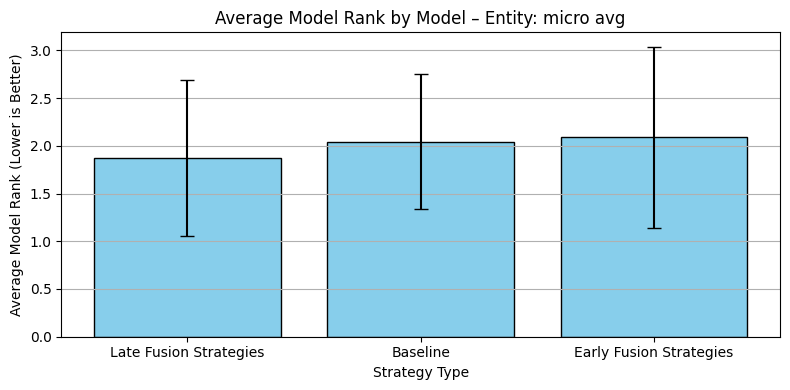

In [163]:
import pandas as pd
import matplotlib.pyplot as plt

# Strategy map
strategy_map = {
    "baseline": "Baseline",
    "early-cross-attention": "Early Fusion Strategies",
    "late-cross-attention": "Late Fusion Strategies",
    "relative": "Late Fusion Strategies",
    "adapter": "Late Fusion Strategies",
    "concat": "Late Fusion Strategies",
    "film": "Late Fusion Strategies"
}

entity = "micro avg"
scope = "year"

df_rank = results_df[
    (results_df["entity_type"] == entity) &
    (results_df["scope"] == scope)
][["strategy", "time", "f1"]].copy()

df_rank["time"] = df_rank["time"].astype(int)
df_rank["strategy"] = df_rank["strategy"].map(strategy_map)

# Rank models per year
rank_matrix = (
    df_rank.pivot_table(index="strategy", columns="time", values="f1", aggfunc="mean")
    .rank(ascending=False)
).reset_index().melt(id_vars="strategy", var_name="time", value_name="rank")

# Group by strategy
summary = (
    rank_matrix.groupby("strategy")["rank"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("mean")
)

# --- Plot manually using matplotlib ---
plt.figure(figsize=(8, 4))
x = range(len(summary))
plt.bar(x, summary["mean"], yerr=summary["std"], capsize=5, color="skyblue", edgecolor="black")
plt.xticks(x, summary["strategy"])
plt.ylabel("Average Model Rank (Lower is Better)")
plt.xlabel("Strategy Type")
plt.title(f"Average Model Rank by Model – Entity: {entity}")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [167]:
# # Collapse across all configs to get average improvement per year + entity_type

# for scope in merged["scope"].unique():
#     df = merged[merged["scope"] == scope]
#     heatmap_data = (
#         df.groupby(["entity_type", "time"])["f1_improvement"]
#         .mean()
#         .unstack("time")
#     )
    
#     plt.figure(figsize=(14, 4))
#     sns.heatmap(
#         heatmap_data,
#         cmap="RdYlGn",  # green = better, red = worse
#         center=0,
#         annot=False,
#         fmt=".2f",
#         linewidths=0.5,
#         linecolor='gray',
#         cbar_kws={'label': 'Avg F1 Improvement over Baseline'}
#     )
#     plt.title(f"Average F1 Improvement over Baseline by Entity Type and Year (All Models) ({scope})")
#     plt.xlabel("Year")
#     plt.ylabel("Entity Type")
#     plt.tight_layout()
#     plt.show()

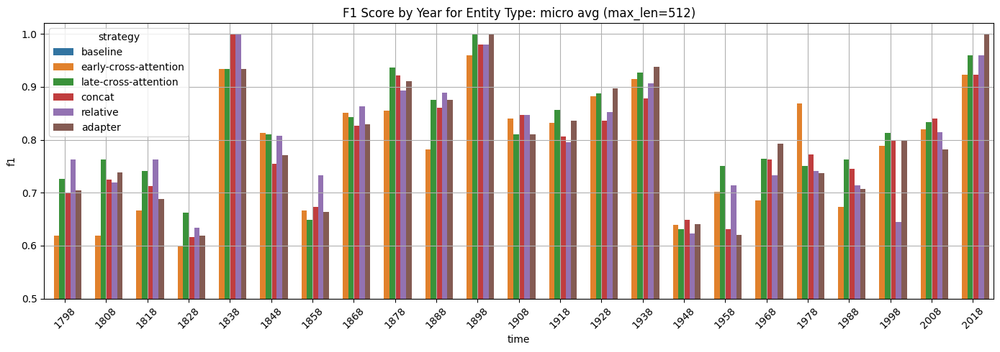

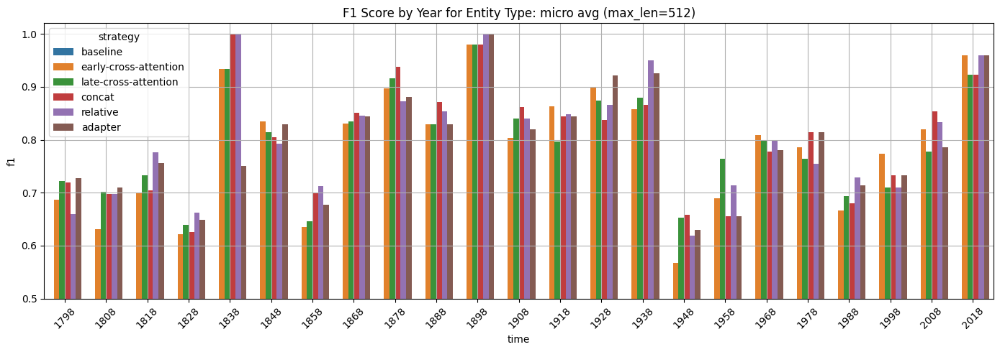

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

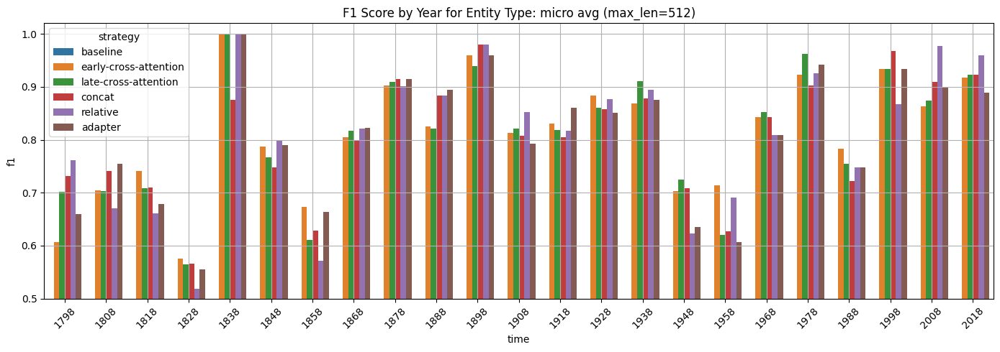

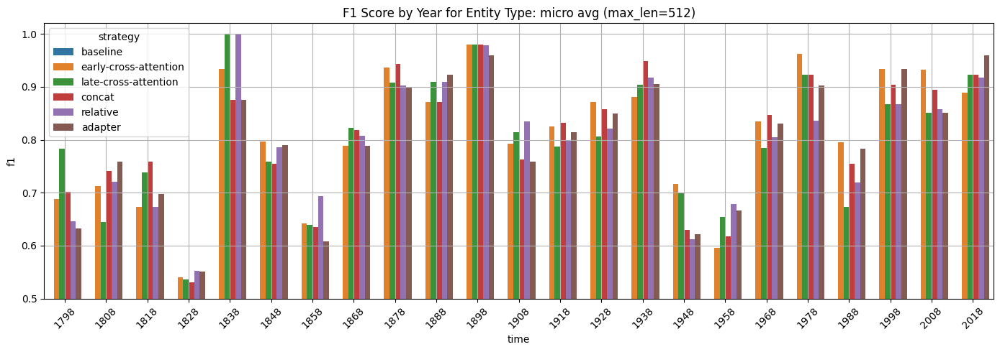

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

In [168]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure matching types
# entity_stats_df["year"] = entity_stats_df["year"].astype(int)
# results_df["time"] = results_df["time"].astype(int)

for base_model in results_df["base_model"].unique():
    for max_len in results_df["max_len"].unique():
        for relative_year in results_df["relative_year"].unique():
            df = results_df[results_df["base_model"] == base_model]
            df = df[df["relative_year"] == relative_year]
            df = df[df["max_len"] == max_len]
            
        
            # for entity in sorted(results_df["entity_type"].unique()):
            for entity in ["micro avg"]:
                plt.figure(figsize=(14, 5))
        
                # Filter result data
                plot_data = df[(df["scope"] == "year") & (df["entity_type"] == entity)]
        
                if plot_data.empty:
                    continue  # Skip if there's nothing to plot
        
                sns.barplot(
                    data=plot_data,
                    x="time", y="f1", hue="strategy"
                )
        
                # Filter and annotate stats
                stats_filtered = entity_stats_df[
                    (entity_stats_df["entity_type"] == entity) & 
                    (entity_stats_df["split"] == "test") & 
                    (entity_stats_df["year"].isin(plot_data["time"]))
                ]
        
                for _, row in stats_filtered.iterrows():
                    plt.annotate(
                        f'n={row["count"]}', 
                        xy=(row["year"], 0.51), 
                        textcoords="offset points", 
                        xytext=(0, 5),
                        ha='center', fontsize=8, color='gray'
                    )
        
                plt.title(f"F1 Score by Year for Entity Type: {entity} (max_len={max_len})")
                plt.xticks(rotation=45)
                plt.ylim(0.5, 1.02)
                plt.grid(True)
                plt.tight_layout()
                plt.show()

In [171]:
results_df['relative_year'] = results_df['strategy'].str.extract(r'(True|False)$')[0]
results_df.tail()

,scope,time,entity_type,precision,recall,f1,run,run_clean,strategy,max_len,base_model,relative_year,temporal_mode,strategy_type
5167,year,1948,time,NaN,NaN,0.55390,None,None,baseline,None,dbmdz_bert_base_historic,NaN,No Temporal Info,Baseline
5168,decade,1950s,time,NaN,NaN,0.90415,None,None,baseline,None,dbmdz_bert_base_historic,NaN,No Temporal Info,Baseline
5169,year,1958,time,NaN,NaN,0.90415,None,None,baseline,None,dbmdz_bert_base_historic,NaN,No Temporal Info,Baseline
5170,decade,1960s,time,NaN,NaN,0.87120,None,None,baseline,None,dbmdz_bert_base_historic,NaN,No Temporal Info,Baseline
5171,year,1968,time,NaN,NaN,0.87120,None,None,baseline,None,dbmdz_bert_base_historic,NaN,No Temporal Info,Baseline


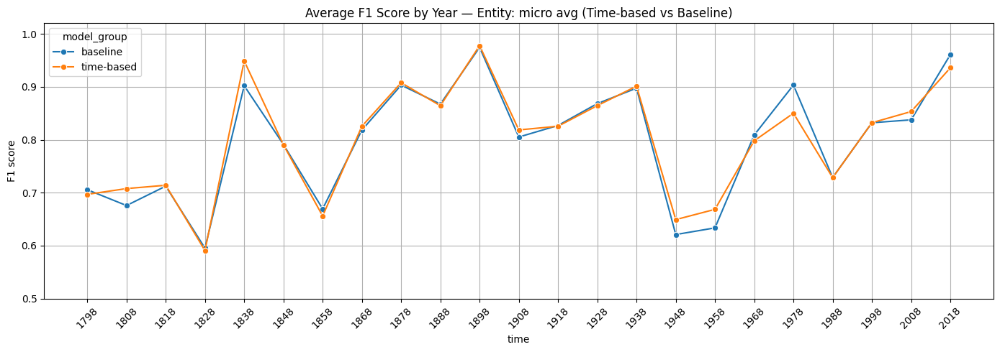

In [172]:
def classify_model_group(model_name):
    return "baseline" if "baseline" in model_name else "time-based"

results_df["model_group"] = results_df["strategy"].apply(classify_model_group)

grouped_df = (
    results_df[(results_df["scope"] == "year")]
    .groupby(["time", "entity_type", "model_group"], as_index=False)
    .agg({"f1": "mean"})
)
grouped_df = grouped_df[grouped_df["entity_type"] == "micro avg"]

for entity in sorted(grouped_df["entity_type"].unique()):
    plot_data = grouped_df[grouped_df["entity_type"] == entity]
    if plot_data.empty:
        continue

    plt.figure(figsize=(14, 5))
    sns.lineplot(data=plot_data, x="time", y="f1", hue="model_group", marker="o")
    plt.title(f"Average F1 Score by Year — Entity: {entity} (Time-based vs Baseline)")
    plt.ylabel("F1 score")
    plt.ylim(0.5, 1.02)
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [173]:
# Optional: Add boolean column for which group had higher mean F1 at each year/entity
def compare_groups(df):
    pivot = df.pivot(index="time", columns="model_group", values="f1")
    pivot["time-based_better"] = pivot["time-based"] > pivot["baseline"]
    return pivot

# Per entity-type comparison table
for entity in grouped_df["entity_type"].unique():
    print(f"\nEntity: {entity}")
    comparison = compare_groups(grouped_df[grouped_df["entity_type"] == entity])
    print(comparison[["time-based_better"]])


Entity: micro avg
model_group  time-based_better
time                          
1798                     False
1808                      True
1818                      True
1828                     False
1838                      True
1848                     False
1858                     False
1868                      True
1878                      True
1888                     False
1898                      True
1908                      True
1918                     False
1928                     False
1938                      True
1948                      True
1958                      True
1968                     False
1978                     False
1988                     False
1998                      True
2008                      True
2018                     False


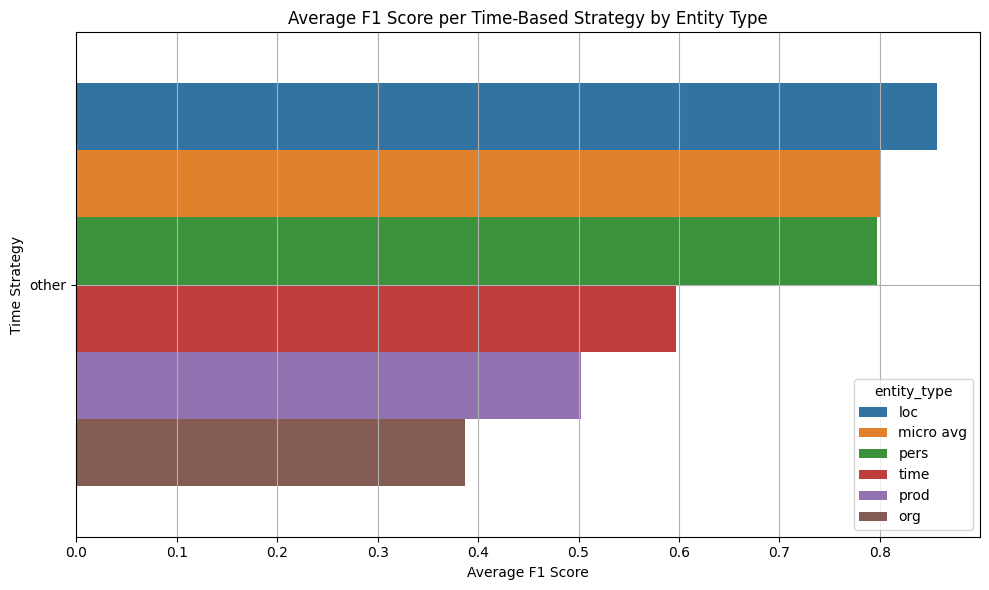

In [174]:
def get_time_strategy(model_name):
    if "baseline" in model_name:
        return "baseline"
    elif model_name.startswith("time."):
        return model_name.replace(".True", "").replace(".False", "")
    else:
        return "other"

results_df["time_strategy"] = results_df["strategy"].apply(get_time_strategy)


time_methods_df = results_df[
    (results_df["scope"] == "year") &
    (results_df["time_strategy"] != "baseline")
]

avg_by_method = (
    time_methods_df
    .groupby(["entity_type", "time_strategy"], as_index=False)
    .agg(mean_f1=("f1", "mean"), std_f1=("f1", "std"))
    .sort_values("mean_f1", ascending=False)
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_by_method, x="mean_f1", y="time_strategy", hue="entity_type")
plt.xlabel("Average F1 Score")
plt.ylabel("Time Strategy")
plt.title("Average F1 Score per Time-Based Strategy by Entity Type")
plt.grid(True)
plt.tight_layout()
plt.show()

In [175]:
import pandas as pd
import requests
from io import StringIO
from typing import List, Optional
from datetime import datetime

class Entity:
    def __init__(self, surface: str, type: str, subtype: str, name: Optional[str] = None,
                 title: Optional[str] = None, function: Optional[str] = None, wkd_id: Optional[str] = None, date: Optional[str] = None):
        """
        Initialize an Entity object.

        Args:
            surface (str): The full surface form of the entity (e.g., "Charlotte née Bourgoin").
            type (str): The coarse type of the entity (e.g., "pers").
            subtype (str): The fine subtype of the entity (e.g., "pers.ind").
            name (Optional[str]): The name component of the entity, if available.
            title (Optional[str]): The title component of the entity, if available.
            function (Optional[str]): The function component of the entity, if available.
            wkd_id (Optional[str]): The Wikidata ID or NIL if not linked.
            date (Optional[str]): The date of the content item.

        """
        self.surface = surface
        self.type = type
        self.subtype = subtype
        self.name = name
        self.title = title
        self.function = function
        self.wkd_id = wkd_id
        self.date = date

    def __repr__(self):
        """
        String representation of the Entity object.
        """
        return (f"Entity(surface={self.surface!r}, type={self.type!r}, subtype={self.subtype!r}, "
                f"name={self.name!r}, title={self.title!r}, function={self.function!r}, wkd_id={self.wkd_id!r}, date={self.date!r})")

    def to_dict(self) -> dict:
        """
        Convert the Entity object to a dictionary.

        Returns:
            dict: A dictionary representation of the Entity.
        """
        return {
            "surface": self.surface,
            "type": self.type,
            "subtype": self.subtype,
            "name": self.name,
            "title": self.title,
            "function": self.function,
            "wkd_id": self.wkd_id,
            "date": self.date
        }


In [176]:
def extract_iob_entities(dataframe: pd.DataFrame) -> List[Entity]:
    """
    Extract IOB entities from the entire DataFrame.

    Args:
        dataframe (pd.DataFrame): The entire dataset with IOB tagging.

    Returns:
        List[Entity]: A list of extracted Entity objects with detailed attributes.
    """
    entities = []
    current_surface = []
    current_type = None
    current_subtype = None
    current_name = []
    current_title = []
    current_function = []
    current_wkd_id = None
    tokens = []
    labels = []
    for _, row in dataframe.iloc[1:].iterrows():
        # hipe2022:date = 1948-12-27
        if type(row["TOKEN"]) == str:
            if ":date" in row["TOKEN"]:
                raw_date = row["TOKEN"].split('=')[-1].strip()
                try:
                    # Parse the extracted date into a datetime object
                    date = datetime.strptime(raw_date, "%Y-%m-%d")
                except ValueError as e:
                    print(f"Invalid date format: {raw_date}. Error: {e}")
            
            if isinstance(row["TOKEN"], str) and "# " not in row["TOKEN"]:
                token = row["TOKEN"]
                tokens.append(token)
                
                coarse_lit = row["NE-COARSE-LIT"]
                fine_lit = row["NE-FINE-LIT"]
                fine_meto = row["NE-FINE-METO"]
                fine_comp = row["NE-FINE-COMP"]
                ne_nested = row["NE-NESTED"]
                nel_lit = row["NEL-LIT"]

                labels.append(coarse_lit)
                # if 'comp' in fine_comp:
                    # if 'O' in coarse_lit:
                    #     print(f".       {token} ({coarse_lit}) -- entity with `comp` [{fine_comp}] without `coarse` type")
                
                # Start a new entity when a "B-" tag is encountered
                if coarse_lit.startswith("B-"):
                    # Save the previous entity if one exists
                    if current_surface:
                        entities.append(Entity(
                            surface=" ".join(current_surface),
                            type=current_type,
                            subtype=current_subtype[2:],  # Remove "B-" or "I-"
                            name=" ".join(current_name) if current_name else None,
                            title=" ".join(current_title) if current_title else None,
                            function=" ".join(current_function) if current_function else None,
                            wkd_id=current_wkd_id,
                            date=date
                        ))
    
                    # Reset and initialize a new entity
                    current_surface = [token]
                    current_type = coarse_lit[2:]  # Extract the type (e.g., "pers")
                    current_subtype = fine_lit
                    current_name = [token] if "name" in fine_comp else []
                    current_title = [token] if "title" in fine_comp else []
                    current_function = [token] if "function" in fine_comp else []
                    current_wkd_id = nel_lit
                    # if 'Théodore' in current_surface:
                    #     print(current_surface, current_function, '---', tokens[-10:], labels[-10:])
    
                # Continue the current entity when an "I-" tag is encountered
                elif coarse_lit.startswith("I-") and current_type == coarse_lit[2:]:
                    current_surface.append(token)
                    if "name" in fine_comp:
                        current_name.append(token)  # Update name with the current token
                    elif "title" in fine_comp:
                        current_title.append(token)  # Update title if specified
                    elif "function" in fine_comp:
                        current_function.append(token)  # Update function if specified
                    # if 'Théodore' in current_surface:
                    #     print(current_surface, current_function, '---', tokens[-10:], labels[-10:])
    
                # Outside tag (O or no entity)
                else:
                    if current_surface:
                        entities.append(Entity(
                            surface=" ".join(current_surface),
                            type=current_type,
                            subtype=current_subtype[2:],  # Remove "B-" or "I-"
                            name=" ".join(current_name),
                            title=" ".join(current_title),
                            function=" ".join(current_function),
                            wkd_id=current_wkd_id,
                            date=date
                        ))
                        # Reset entity information
                        current_surface = []
                        current_type = None
                        current_subtype = None
                        current_name = []
                        current_title = []
                        current_function = []
                        current_wkd_id = None

    # Save any remaining entity at the end of the DataFrame
    if current_surface:
        entities.append(Entity(
            surface=" ".join(current_surface),
            type=current_type,
            subtype=current_subtype[2:],  # Remove "B-" or "I-"
            name=current_name,
            title=current_title,
            function=current_function,
            wkd_id=current_wkd_id
        ))

    return entities


In [177]:
import os
import pandas as pd
from collections import defaultdict

def build_datasets_structure(base_path: str):
    """
    Build the datasets structure dynamically while walking through the directory.

    Args:
        base_path (str): The base directory to walk through.

    Returns:
        dict: A nested dictionary representing the datasets structure.
    """
    datasets = {}

    for root, dirs, files in os.walk(base_path):
        for file in files:
            print(file)
            if file.endswith(".tsv"):  # Only process TSV files
                # Extract dataset, language, and dataset type from the directory structure
                dataset, language = root.split('/')[-2:]
                for dataset_type in ['train', 'test', 'dev']:
                    if f"{dataset_type}-{language}" in file:
                        file_path = os.path.join(root, file)
                        if dataset not in datasets:
                            datasets[dataset] = {}
                        if language not in datasets[dataset]:
                            datasets[dataset][language] = {}
                        if dataset_type not in datasets[dataset][language]:
                            datasets[dataset][language][dataset_type] = file_path
    return datasets

# Build the datasets structure from the base path
base_path = "../data/hipe2020/"
datasets = build_datasets_structure(base_path)
datasets

.DS_Store
HIPE-2022-v2.1-hipe2020-dev-de.tsv
HIPE-2022-v2.1-hipe2020-test_ELmasked-de.tsv
HIPE-2022-v2.1-hipe2020-test_allmasked-de.tsv
HIPE-2022-v2.1-hipe2020-test-de.tsv
HIPE-2022-v2.1-hipe2020-train-de.tsv
HIPE-2022-v2.1-hipe2020-test_ELmasked-fr.tsv
HIPE-2022-v2.1-hipe2020-test_allmasked-fr.tsv
HIPE-2022-v2.1-hipe2020-train-fr.tsv
HIPE-2022-v2.1-hipe2020-test-fr.tsv
HIPE-2022-v2.1-hipe2020-dev-fr.tsv
HIPE-2022-v2.1-hipe2020-test_allmasked-en.tsv
HIPE-2022-v2.1-hipe2020-test-en.tsv
HIPE-2022-v2.1-hipe2020-test_ELmasked-en.tsv
HIPE-2022-v2.1-hipe2020-dev-en.tsv


{'hipe2020': {'de': {'dev': '../data/hipe2020/de/HIPE-2022-v2.1-hipe2020-dev-de.tsv',
   'test': '../data/hipe2020/de/HIPE-2022-v2.1-hipe2020-test-de.tsv',
   'train': '../data/hipe2020/de/HIPE-2022-v2.1-hipe2020-train-de.tsv'},
  'fr': {'train': '../data/hipe2020/fr/HIPE-2022-v2.1-hipe2020-train-fr.tsv',
   'test': '../data/hipe2020/fr/HIPE-2022-v2.1-hipe2020-test-fr.tsv',
   'dev': '../data/hipe2020/fr/HIPE-2022-v2.1-hipe2020-dev-fr.tsv'},
  'en': {'test': '../data/hipe2020/en/HIPE-2022-v2.1-hipe2020-test-en.tsv',
   'dev': '../data/hipe2020/en/HIPE-2022-v2.1-hipe2020-dev-en.tsv'}}}

In [178]:
datasets['hipe2020']['fr']['test']

'../data/hipe2020/fr/HIPE-2022-v2.1-hipe2020-test-fr.tsv'

In [179]:
import csv

data_gt = pd.read_csv('../data/hipe2020/fr/HIPE-2022-v2.1-hipe2020-test-fr.tsv', sep='\t', on_bad_lines='skip', encoding='utf-8', quoting=csv.QUOTE_NONE, engine='python')
data_gt.head()

,TOKEN,NE-COARSE-LIT,NE-COARSE-METO,NE-FINE-LIT,NE-FINE-METO,NE-FINE-COMP,NE-NESTED,NEL-LIT,NEL-METO,MISC
0,# hipe2022:document_id = EXP-1798-01-04-a-i0005,None,None,None,None,None,None,None,None,None
1,# hipe2022:date = 1798-01-04,None,None,None,None,None,None,None,None,None
2,# hipe2022:language = fr,None,None,None,None,None,None,None,None,None
3,# hipe2022:document_type = newspaper,None,None,None,None,None,None,None,None,None
4,# hipe2022:dataset = hipe2020,None,None,None,None,None,None,None,None,None


In [180]:
entities_gt = extract_iob_entities(data_gt)

entities_gt[:3]

[Entity(surface='Charlotte née Bourgoin', type='pers', subtype='pers.ind', name='Bourgoin', title='', function='', wkd_id='NIL', date=datetime.datetime(1798, 1, 4, 0, 0)),
 Entity(surface='Joseph Digiez', type='pers', subtype='pers.ind', name='Digiez', title='', function='', wkd_id='NIL', date=datetime.datetime(1798, 1, 4, 0, 0)),
 Entity(surface='Maurice Bourgoin', type='pers', subtype='pers.ind', name='Bourgoin', title='', function='', wkd_id='NIL', date=datetime.datetime(1798, 1, 4, 0, 0))]

In [181]:
entities_gt[0]

Entity(surface='Charlotte née Bourgoin', type='pers', subtype='pers.ind', name='Bourgoin', title='', function='', wkd_id='NIL', date=datetime.datetime(1798, 1, 4, 0, 0))

In [182]:
entities_gt[0]

Entity(surface='Charlotte née Bourgoin', type='pers', subtype='pers.ind', name='Bourgoin', title='', function='', wkd_id='NIL', date=datetime.datetime(1798, 1, 4, 0, 0))

In [183]:
import os
import pandas as pd
import csv
from typing import List, Dict
from datetime import datetime
from dataclasses import dataclass
from collections import defaultdict, Counter

def get_time_bin(date: datetime, mode: str) -> str:
    if not date or pd.isnull(date):
        return "unknown"
    if mode == "year":
        return str(date.year)
    elif mode == "decade":
        return f"{date.year // 10 * 10}s"
    elif mode == "century":
        return f"{(date.year // 100 + 1)}th c."
    else:
        raise ValueError(f"Invalid mode: {mode}")

# Compute metrics between GT and PRED for a specific bin (e.g., a decade)
def compute_metrics(gt: List, pred: List) -> Dict:
    gt_counter = Counter((e.surface.lower(), e.type) for e in gt)
    pred_counter = Counter((e.surface.lower(), e.type) for e in pred)

    tp = sum((gt_counter & pred_counter).values())
    fp = sum((pred_counter - gt_counter).values())
    fn = sum((gt_counter - pred_counter).values())

    precision = tp / (tp + fp) if tp + fp > 0 else 0.0
    recall = tp / (tp + fn) if tp + fn > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0

    return dict(TP=tp, FP=fp, FN=fn, precision=precision, recall=recall, f1=f1)

def load_all_predictions_with_metrics(entities_gt: List, results_path: str = "../results") -> pd.DataFrame:
    all_results = []

    time_modes = ["year", "decade", "century"]

    for mode in time_modes:
        # Bin GT by time
        gt_by_time = defaultdict(list)
        for e in entities_gt:
            gt_by_time[get_time_bin(e.date, mode)].append(e)

        for folder_name in os.listdir(results_path):
            folder_path = os.path.join(results_path, folder_name)
            if not os.path.isdir(folder_path):
                continue

            is_relative_time = folder_name.strip().endswith("True")
            prediction_file = os.path.join(folder_path, "HIPE-2022-v2.1-hipe2020-test-fr_pred.tsv")

            if not os.path.exists(prediction_file):
                print(f"⚠️ File not found: {prediction_file}")
                continue

            df_pred = pd.read_csv(
                prediction_file,
                sep='\t',
                on_bad_lines='skip',
                encoding='utf-8',
                quoting=csv.QUOTE_NONE,
                engine='python'
            )
            entities_pred = extract_iob_entities(df_pred)
            model = get_model_type(folder_name).replace('time-', '')
            model_type = "baseline" if "baseline" in folder_name else "time-based"
            base_model = get_base_model(folder_name)
            max_len = get_max_len(folder_name)

            # Bin predictions by time
            pred_by_time = defaultdict(list)
            for e in entities_pred:
                pred_by_time[get_time_bin(e.date, mode)].append(e)

            # Evaluate each bin
            all_bins = set(gt_by_time.keys()) | set(pred_by_time.keys())
            for time_bin in sorted(all_bins):
                gt = gt_by_time[time_bin]
                pred = pred_by_time[time_bin]
                metrics = compute_metrics(gt, pred)
                all_results.append({
                    "experiment": folder_name,
                    "model": model.split('.')[0],
                    "model_type": model_type,
                    "base_model": base_model,
                    "max_len": max_len,
                    "is_relative_time": is_relative_time,
                    "time_bin_type": mode,
                    "time_bin": time_bin,
                    "entities": entities_pred,
                    **metrics
                })
            print(f"✅ Evaluated {folder_name} on {mode}")

    return pd.DataFrame(all_results)

In [184]:
all_predictions = load_all_predictions_with_metrics(entities_gt, "../results")

✅ Evaluated model_dbmdz_bert_base_historic_multilingual_cased_max_sequence_length_512_epochs_3_run_time-swiglu.concat.False on year
✅ Evaluated model_dbmdz_bert_base_historic_multilingual_cased_max_sequence_length_512_epochs_3_run_time-swiglu.relative.True on year
✅ Evaluated model_bert_base_multilingual_cased_max_sequence_length_512_epochs_3_run_time-swiglu.baseline.True on year
✅ Evaluated model_dbmdz_bert_base_historic_multilingual_cased_max_sequence_length_512_epochs_3_run_time-swiglu.concat.True on year
✅ Evaluated model_bert_base_multilingual_cased_max_sequence_length_512_epochs_3_run_time-swiglu.late-cross-attention.False on year
✅ Evaluated model_bert_base_multilingual_cased_max_sequence_length_512_epochs_3_run_time-swiglu.adapter.False on year
✅ Evaluated model_dbmdz_bert_base_historic_multilingual_cased_max_sequence_length_512_epochs_3_run_time-swiglu.late-cross-attention.True on year
✅ Evaluated model_dbmdz_bert_base_historic_multilingual_cased_max_sequence_length_512_epochs

In [185]:
if "relative_year" not in all_predictions.columns:
    all_predictions['relative_year'] = all_predictions['experiment'].str.extract(r'(True|False)$')[0]
print(all_predictions['relative_year'].unique())


all_predictions["relative_year"] = all_predictions["relative_year"].astype(str).str.lower() == "true"
all_predictions["temporal_mode"] = all_predictions["relative_year"].map({True: "Time Distance", False: "Absolute"})

['False' 'True']


In [186]:
all_predictions.iloc[0].entities[:5]


[Entity(surface='G R E E F E', type='loc', subtype='', name='', title='', function='', wkd_id='_', date=datetime.datetime(1798, 1, 4, 0, 0)),
 Entity(surface='Charlotte née Bourgoin', type='pers', subtype='pers.ind', name='Bourgoin', title='', function='', wkd_id='NIL', date=datetime.datetime(1798, 1, 4, 0, 0)),
 Entity(surface='Joseph Digiez', type='pers', subtype='pers.ind', name='Digiez', title='', function='', wkd_id='NIL', date=datetime.datetime(1798, 1, 4, 0, 0)),
 Entity(surface='Maurice Bourgoin , enfant mineur', type='pers', subtype='pers.ind', name='Bourgoin', title='', function='', wkd_id='NIL', date=datetime.datetime(1798, 1, 4, 0, 0)),
 Entity(surface='sieur Jaques Charles Gicot son curateur', type='pers', subtype='pers.ind', name='Gicot', title='sieur', function='', wkd_id='NIL', date=datetime.datetime(1798, 1, 4, 0, 0))]

In [187]:
all_predictions.head()


,experiment,model,model_type,base_model,max_len,is_relative_time,time_bin_type,time_bin,entities,TP,FP,FN,precision,recall,f1,relative_year,temporal_mode
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"[Entity(surface='G R E E F E', type='loc', sub...",34,16,11,0.680000,0.755556,0.715789,False,Absolute
1,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1808,"[Entity(surface='G R E E F E', type='loc', sub...",49,24,13,0.671233,0.790323,0.725926,False,Absolute
2,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1818,"[Entity(surface='G R E E F E', type='loc', sub...",39,22,26,0.639344,0.600000,0.619048,False,Absolute
3,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1828,"[Entity(surface='G R E E F E', type='loc', sub...",79,71,38,0.526667,0.675214,0.591760,False,Absolute
4,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1838,"[Entity(surface='G R E E F E', type='loc', sub...",8,0,0,1.000000,1.000000,1.000000,False,Absolute


In [188]:
len(all_predictions[all_predictions["model"] == "baseline"])

200

In [189]:
all_predictions

,experiment,model,model_type,base_model,max_len,is_relative_time,time_bin_type,time_bin,entities,TP,FP,FN,precision,recall,f1,relative_year,temporal_mode
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"[Entity(surface='G R E E F E', type='loc', sub...",34,16,11,0.680000,0.755556,0.715789,False,Absolute
1,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1808,"[Entity(surface='G R E E F E', type='loc', sub...",49,24,13,0.671233,0.790323,0.725926,False,Absolute
2,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1818,"[Entity(surface='G R E E F E', type='loc', sub...",39,22,26,0.639344,0.600000,0.619048,False,Absolute
3,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1828,"[Entity(surface='G R E E F E', type='loc', sub...",79,71,38,0.526667,0.675214,0.591760,False,Absolute
4,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1838,"[Entity(surface='G R E E F E', type='loc', sub...",8,0,0,1.000000,1.000000,1.000000,False,Absolute
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,model_dbmdz_bert_base_historic_multilingual_ca...,baseline,baseline,dbmdz_bert_base_historic,512,True,century,21th c.,"[Entity(surface='G R E E F E', type='pers', su...",46,5,12,0.901961,0.793103,0.844037,True,Time Distance
1196,model_bert_base_multilingual_cased_max_sequenc...,adapter,time-based,bert_base_multilingual_cased,512,True,century,18th c.,"[Entity(surface='Charlotte née Bourgoin', type...",30,16,15,0.652174,0.666667,0.659341,True,Time Distance
1197,model_bert_base_multilingual_cased_max_sequenc...,adapter,time-based,bert_base_multilingual_cased,512,True,century,19th c.,"[Entity(surface='Charlotte née Bourgoin', type...",537,205,229,0.723720,0.701044,0.712202,True,Time Distance
1198,model_bert_base_multilingual_cased_max_sequenc...,adapter,time-based,bert_base_multilingual_cased,512,True,century,20th c.,"[Entity(surface='Charlotte née Bourgoin', type...",576,130,155,0.815864,0.787962,0.801670,True,Time Distance


T-test: t = 0.1304, p = 8.9634e-01


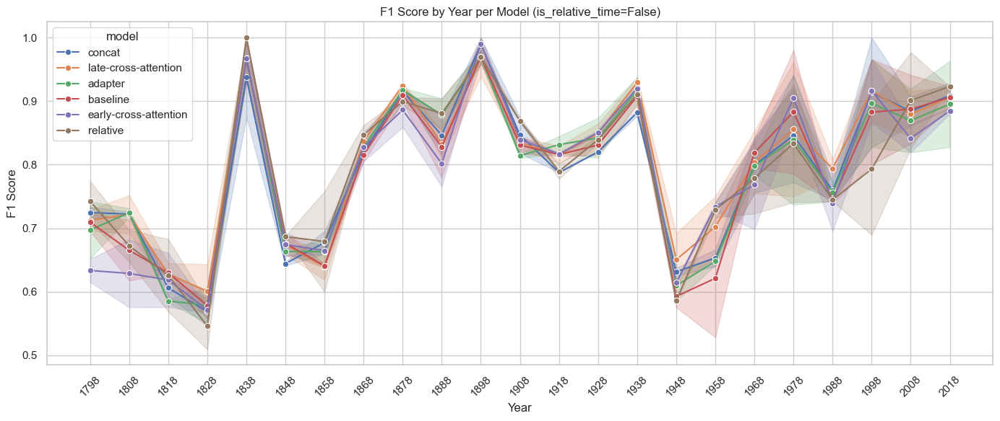

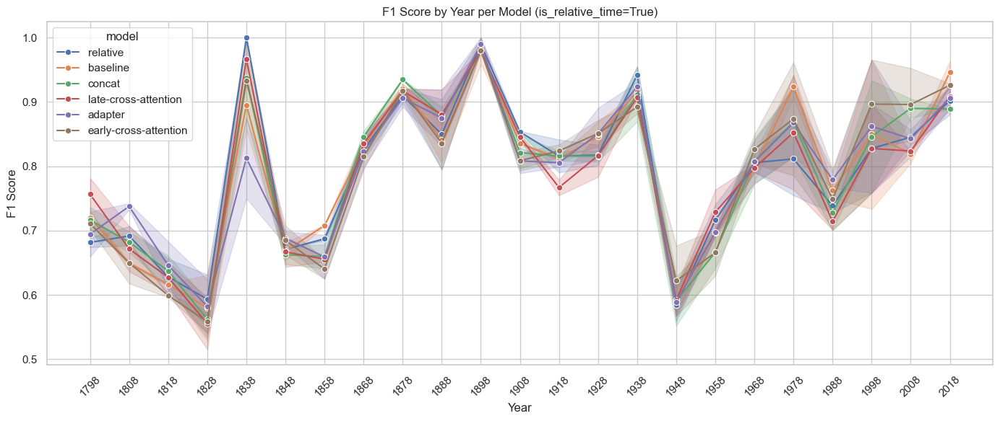

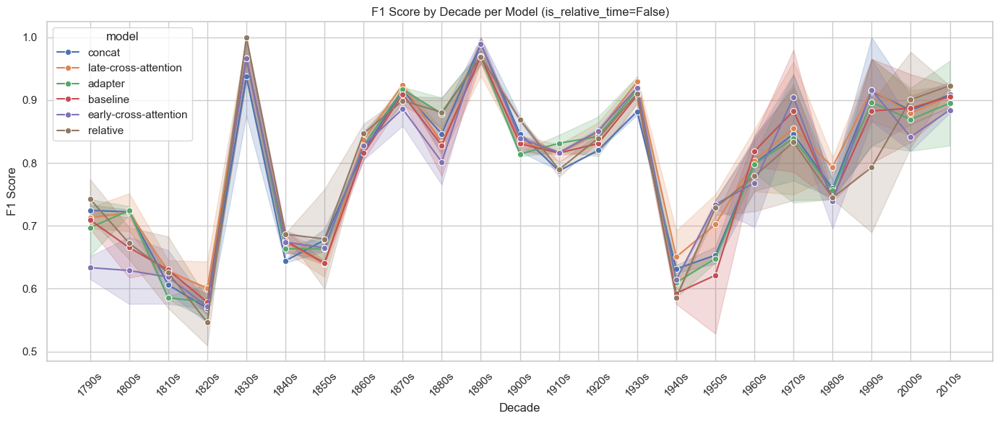

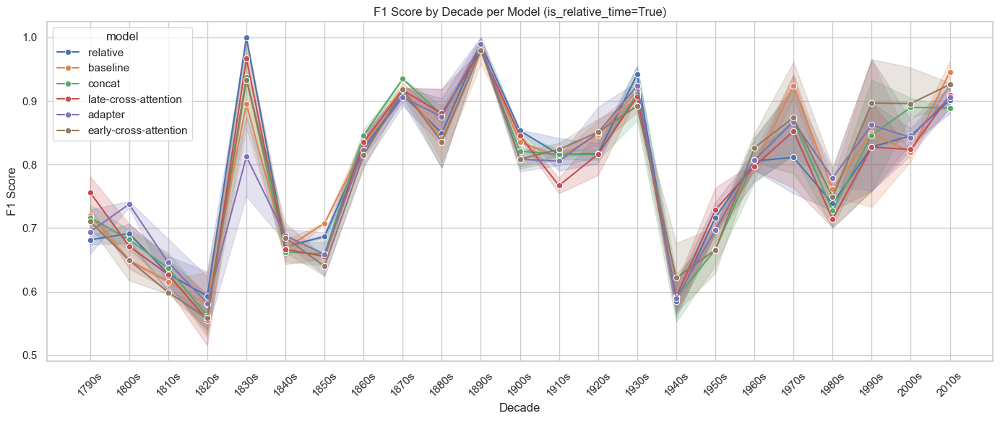

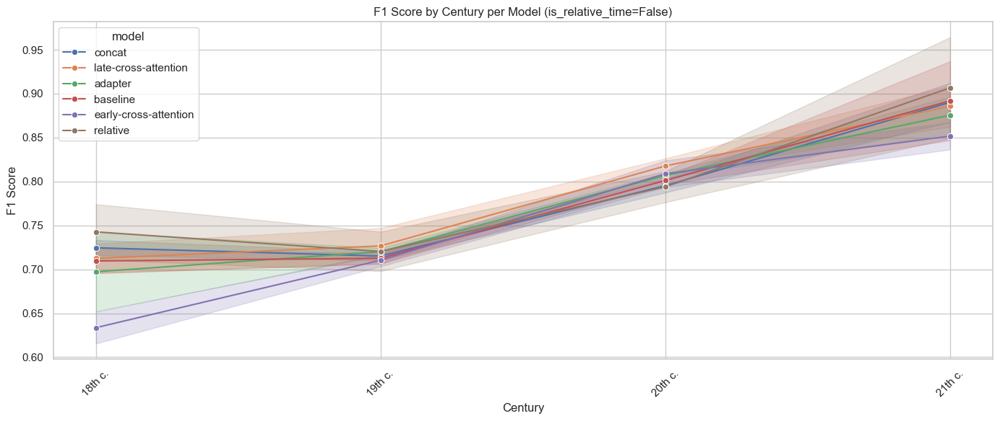

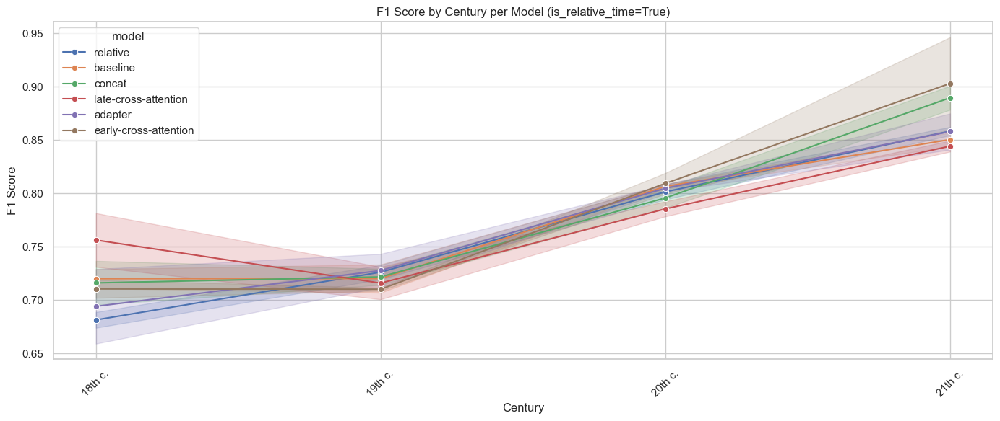

                   model        f1  f1_delta_vs_baseline
4   late-cross-attention  0.793131              0.004713
5               relative  0.790956              0.002538
2                 concat  0.789081              0.000663
0                adapter  0.788650              0.000232
1               baseline  0.788418              0.000000
3  early-cross-attention  0.786333             -0.002084


In [191]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Ensure numeric types and clean data
df = all_predictions.copy()
df["f1"] = pd.to_numeric(df["f1"], errors="coerce")
df["precision"] = pd.to_numeric(df["precision"], errors="coerce")
df["recall"] = pd.to_numeric(df["recall"], errors="coerce")
df = df.dropna(subset=["f1", "model", "model_type", "time_bin_type", "time_bin"])

# 1. Compare average F1 scores for time-based vs baseline
baseline_f1 = df[df["model_type"] == "baseline"]["f1"]
timebased_f1 = df[df["model_type"] == "time-based"]["f1"]

t_stat, p_value = ttest_ind(timebased_f1, baseline_f1, equal_var=False)
print(f"T-test: t = {t_stat:.4f}, p = {p_value:.4e}")

# 2. Group mean F1 per model and time_bin_type (year, decade, century)
grouped_f1 = df.groupby(["model", "time_bin_type"])["f1"].mean().reset_index()

# 3. Visualize F1 over time bins
sns.set(style="whitegrid")
for bin_type in ["year", "decade", "century"]:
    for is_relative_time in [False, True]:
        plt.figure(figsize=(14, 6))
        subset = df[df["is_relative_time"] == is_relative_time]
        subset = subset[subset["time_bin_type"] == bin_type]
        sns.lineplot(data=subset, x="time_bin", y="f1", hue="model", marker="o")
        plt.title(f"F1 Score by {bin_type.title()} per Model (is_relative_time={is_relative_time})")
        plt.xticks(rotation=45)
        plt.ylabel("F1 Score")
        plt.xlabel(bin_type.title())
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# 4. Compute average F1 difference per model vs baseline
avg_f1_per_model = df.groupby("model")["f1"].mean().reset_index()
baseline_mean = baseline_f1.mean()
avg_f1_per_model["f1_delta_vs_baseline"] = avg_f1_per_model["f1"] - baseline_mean
print(avg_f1_per_model.sort_values("f1_delta_vs_baseline", ascending=False))

In [212]:
import pandas as pd
from collections import Counter

# Step 1: Copy the main DataFrame
df = all_predictions.copy()

# Step 2: Flatten and prepare entity surface statistics across models
entity_surface_stats = []

for exp in df["experiment"].unique():
    df_exp = df[df["experiment"] == exp]
    model = df_exp["model"].iloc[0]
    all_pred_entities = []

    for entities in df_exp["entities"]:
        all_pred_entities.extend(entities)

    pred_counter = Counter((e.surface, e.type) for e in all_pred_entities if hasattr(e, 'surface') and hasattr(e, 'type'))

    for (surface, typ), count in pred_counter.items():
        entity_surface_stats.append({
            "model": model,
            "surface": surface,
            "type": typ,
            "count": count
        })


# Step 3: Convert to DataFrame and pivot
entity_surface_df = pd.DataFrame(entity_surface_stats)
pivot_surface = entity_surface_df.pivot_table(index=["surface", "type"], columns="model", values="count", fill_value=0)

# Step 4: Compute gain vs. baseline
baseline_col = "swiglu.baseline.True"
if baseline_col in pivot_surface.columns:
    pivot_surface["gain_vs_baseline"] = pivot_surface.max(axis=1) - pivot_surface[baseline_col]
else:
    pivot_surface["gain_vs_baseline"] = pivot_surface.max(axis=1)

# Step 5: Sort and inspect
pivot_surface_sorted = pivot_surface.sort_values("gain_vs_baseline", ascending=False).reset_index()
pivot_surface_sorted.head(20)

model,surface,type,adapter,baseline,concat,early-cross-attention,late-cross-attention,relative,gain_vs_baseline
0,Suisse,loc,1112.5,1137.5,1125.0,1112.5,1125.0,1112.5,1137.5
1,Berne,loc,1050.0,1012.5,1050.0,1000.0,1000.0,1037.5,1050.0
2,Paris,loc,1025.0,1025.0,1025.0,1025.0,1000.0,1025.0,1025.0
3,France,loc,975.0,962.5,975.0,975.0,962.5,962.5,975.0
4,Berlin,loc,662.5,650.0,687.5,675.0,675.0,675.0,687.5
5,Locle,loc,637.5,675.0,675.0,575.0,587.5,675.0,675.0
6,Italie,loc,612.5,612.5,600.0,612.5,625.0,612.5,625.0
7,Allemagne,loc,550.0,550.0,550.0,550.0,550.0,550.0,550.0
8,Vienne,loc,437.5,450.0,450.0,462.5,437.5,437.5,462.5
9,Genève,loc,387.5,400.0,400.0,400.0,400.0,400.0,400.0


In [216]:
all_predictions.head()

,experiment,model,model_type,base_model,max_len,is_relative_time,time_bin_type,time_bin,entities,TP,FP,FN,precision,recall,f1,relative_year,temporal_mode,strategy
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"[Entity(surface='G R E E F E', type='loc', sub...",34,16,11,0.680000,0.755556,0.715789,False,Absolute,Late Fusion Strategies
1,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1808,"[Entity(surface='G R E E F E', type='loc', sub...",49,24,13,0.671233,0.790323,0.725926,False,Absolute,Late Fusion Strategies
2,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1818,"[Entity(surface='G R E E F E', type='loc', sub...",39,22,26,0.639344,0.600000,0.619048,False,Absolute,Late Fusion Strategies
3,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1828,"[Entity(surface='G R E E F E', type='loc', sub...",79,71,38,0.526667,0.675214,0.591760,False,Absolute,Late Fusion Strategies
4,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1838,"[Entity(surface='G R E E F E', type='loc', sub...",8,0,0,1.000000,1.000000,1.000000,False,Absolute,Late Fusion Strategies


In [219]:
from collections import defaultdict

# Step 1: Create ground truth index
gt_index = Counter((e.surface, e.type) for e in entities_gt)

# Step 2: For each model, count correct predictions
model_tp_counter = defaultdict(Counter)

for exp in all_predictions["experiment"].unique():
    df_exp = all_predictions[all_predictions["experiment"] == exp]
    model = df_exp["model"].iloc[0]

    for _, row in df_exp.iterrows():
        for pred in row["entities"]:
            key = (pred.surface, pred.type)
            if key in gt_index:
                model_tp_counter[model][key] += 1

# Step 3: Compare TPs
entity_surface_stats = []
for key in gt_index:
    surface, typ = key
    baseline_tp = model_tp_counter["swiglu.baseline.True"][key]
    max_tp = max(model_tp_counter[m][key] for m in model_tp_counter)
    gain = max_tp - baseline_tp

    entity_surface_stats.append({
        "surface": surface,
        "type": typ,
        "baseline_tp": baseline_tp,
        "max_tp": max_tp,
        "gain_vs_baseline": gain
    })

# Step 4: Convert to DataFrame and analyze
entity_surface_df = pd.DataFrame(entity_surface_stats)

/var/folders/rv/x6hk7f3j7dzb763m4m3kgmb00000gp/T/ipykernel_5917/3417692971.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


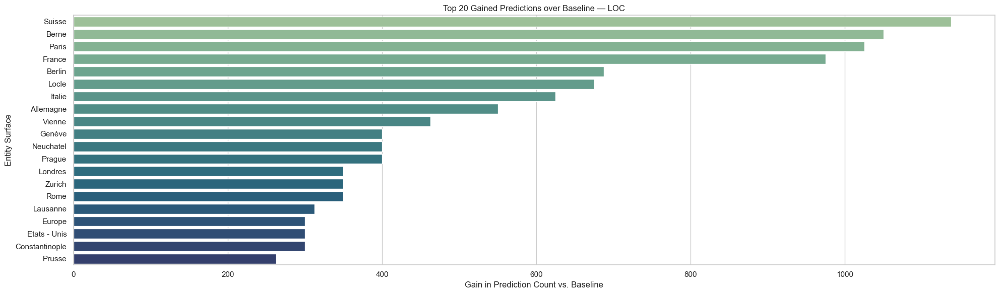

/var/folders/rv/x6hk7f3j7dzb763m4m3kgmb00000gp/T/ipykernel_5917/3417692971.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


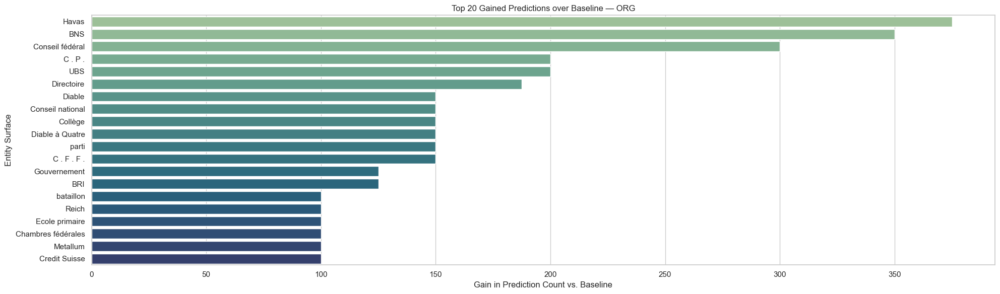

/var/folders/rv/x6hk7f3j7dzb763m4m3kgmb00000gp/T/ipykernel_5917/3417692971.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


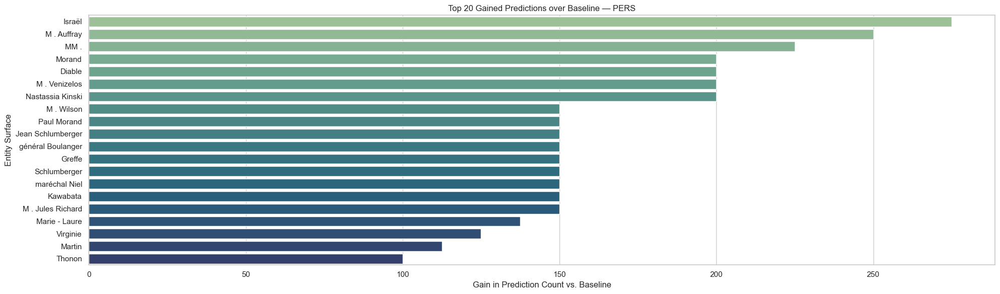

/var/folders/rv/x6hk7f3j7dzb763m4m3kgmb00000gp/T/ipykernel_5917/3417692971.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


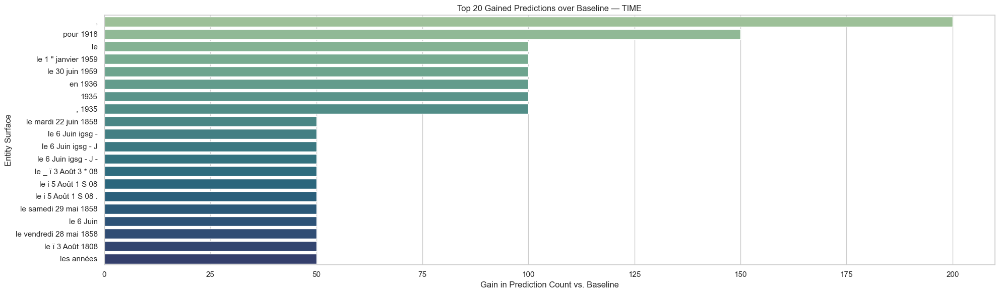

/var/folders/rv/x6hk7f3j7dzb763m4m3kgmb00000gp/T/ipykernel_5917/3417692971.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


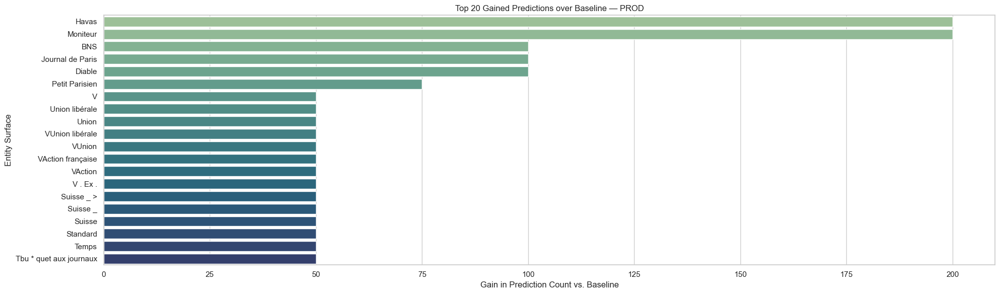

In [215]:
import seaborn as sns
import matplotlib.pyplot as plt

# Number of top entities to show per type
TOP_K = 20

# Create one plot per entity type
for entity_type in pivot_surface_sorted["type"].unique():
    subset = pivot_surface_sorted[pivot_surface_sorted["type"] == entity_type]
    top_entities = subset.nlargest(TOP_K, "gain_vs_baseline")

    plt.figure(figsize=(20, 6))
    sns.barplot(
        data=top_entities,
        x="gain_vs_baseline",
        y="surface",
        palette="crest"
    )
    plt.title(f"Top {TOP_K} Gained Predictions over Baseline — {entity_type.upper()}")
    plt.xlabel("Gain in Prediction Count vs. Baseline")
    plt.ylabel("Entity Surface")
    plt.tight_layout()
    plt.savefig(f"gain_vs_baseline_top_{entity_type}.png", dpi=300)
    plt.show()

In [223]:
len(df), len(all_predictions)

(1200, 1200)

In [226]:
entity_surface_df

,surface,type,baseline_tp,max_tp,gain_vs_baseline
0,Charlotte née Bourgoin,pers,0,200,200
1,Joseph Digiez,pers,0,200,200
2,Maurice Bourgoin,pers,0,150,150
3,sieur Jaques Charles Gicot,pers,0,100,100
4,Conseil d ' Etat,org,0,150,150
...,...,...,...,...,...
1101,Floride,loc,0,200,200
1102,Donald Trump,pers,0,200,200
1103,ONU,org,0,150,150
1104,Sénégal,loc,0,200,200


In [221]:
model_tp_counter.keys()

dict_keys(['concat', 'relative', 'baseline', 'late-cross-attention', 'adapter', 'early-cross-attention', 'swiglu.baseline.True'])

In [218]:
entity_surface_df

,surface,type,baseline_tp,max_tp,gain_vs_baseline
0,charlotte née bourgoin,pers,0,200,200
1,joseph digiez,pers,0,200,200
2,maurice bourgoin,pers,0,150,150
3,sieur jaques charles gicot,pers,0,100,100
4,conseil d ' etat,org,0,150,150
...,...,...,...,...,...
1060,haïti,loc,0,400,400
1061,floride,loc,0,200,200
1062,onu,org,0,150,150
1063,sénégal,loc,0,200,200


In [233]:
all_predictions.head()

,experiment,model,model_type,base_model,max_len,is_relative_time,time_bin_type,time_bin,entities,TP,FP,FN,precision,recall,f1,relative_year,temporal_mode,strategy
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"[Entity(surface='G R E E F E', type='loc', sub...",34,16,11,0.680000,0.755556,0.715789,False,Absolute,Late Fusion Strategies
1,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1808,"[Entity(surface='G R E E F E', type='loc', sub...",49,24,13,0.671233,0.790323,0.725926,False,Absolute,Late Fusion Strategies
2,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1818,"[Entity(surface='G R E E F E', type='loc', sub...",39,22,26,0.639344,0.600000,0.619048,False,Absolute,Late Fusion Strategies
3,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1828,"[Entity(surface='G R E E F E', type='loc', sub...",79,71,38,0.526667,0.675214,0.591760,False,Absolute,Late Fusion Strategies
4,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1838,"[Entity(surface='G R E E F E', type='loc', sub...",8,0,0,1.000000,1.000000,1.000000,False,Absolute,Late Fusion Strategies


In [232]:
from collections import Counter, defaultdict
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Index ground truth
gt_index = Counter((e.surface, e.type) for e in entities_gt)

# Step 2: Count true positives per model
model_tp_counter = defaultdict(Counter)

for exp in all_predictions["experiment"].unique():
    df_exp = all_predictions[all_predictions["experiment"] == exp]
    model = df_exp["model"].iloc[0]

    for _, row in df_exp.iterrows():
        for pred in row["entities"]:
            key = (pred.surface, pred.type)
            if key in gt_index:
                model_tp_counter[model][key] += 1

# Step 3: Compare against baseline
entity_surface_stats = []
baseline_model = "swiglu.baseline.True"

for (surface, typ) in gt_index:
    baseline_tp = model_tp_counter[baseline_model][(surface, typ)]
    max_tp = max(model_tp_counter[m][(surface, typ)] for m in model_tp_counter)
    best_model = max(model_tp_counter, key=lambda m: model_tp_counter[m][(surface, typ)])
    gain = max_tp - baseline_tp

    entity_surface_stats.append({
        "surface": surface,
        "type": typ,
        "baseline_tp": baseline_tp,
        "max_tp": max_tp,
        "gain_vs_baseline": gain,
        "best_model": best_model
    })

entity_surface_df = pd.DataFrame(entity_surface_stats)

In [234]:
entity_surface_df.head()

,surface,type,baseline_tp,max_tp,gain_vs_baseline,best_model
0,Charlotte née Bourgoin,pers,0,200,200,baseline
1,Joseph Digiez,pers,0,200,200,concat
2,Maurice Bourgoin,pers,0,150,150,relative
3,sieur Jaques Charles Gicot,pers,0,100,100,concat
4,Conseil d ' Etat,org,0,150,150,concat


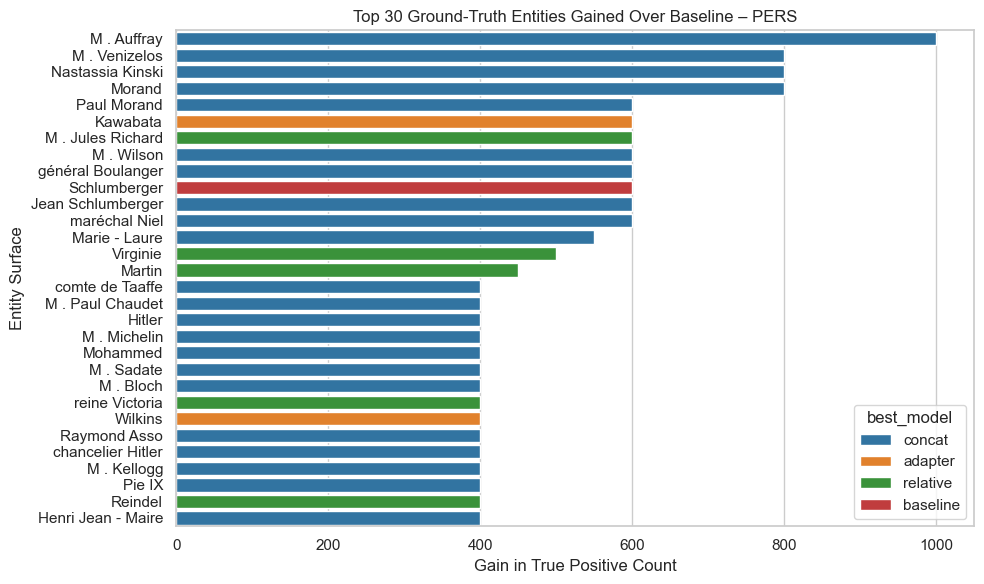

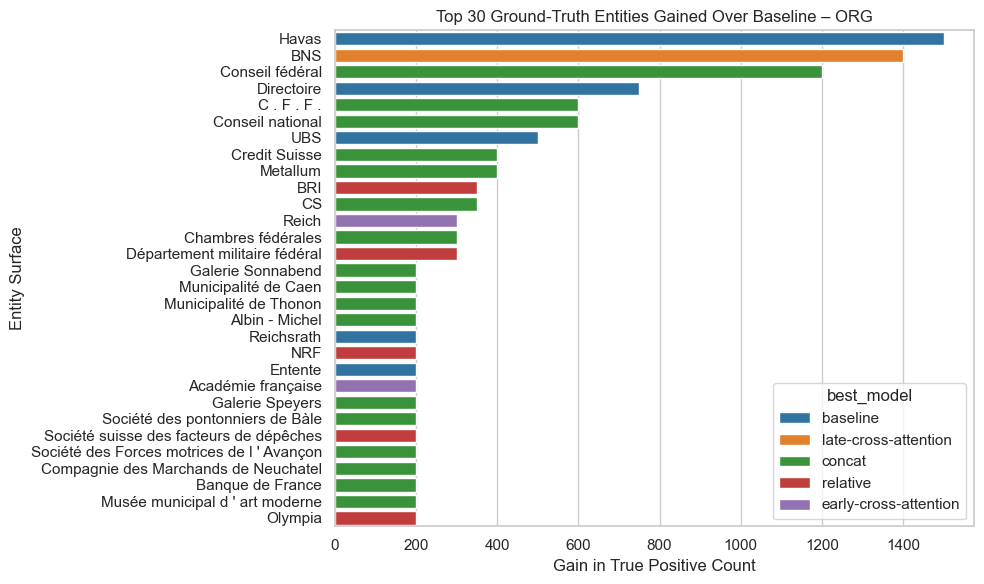

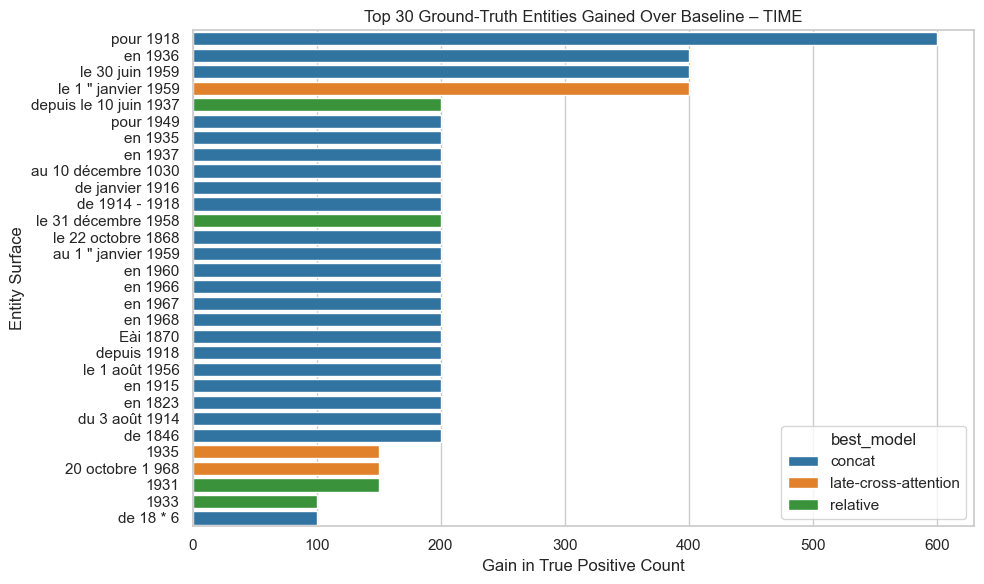

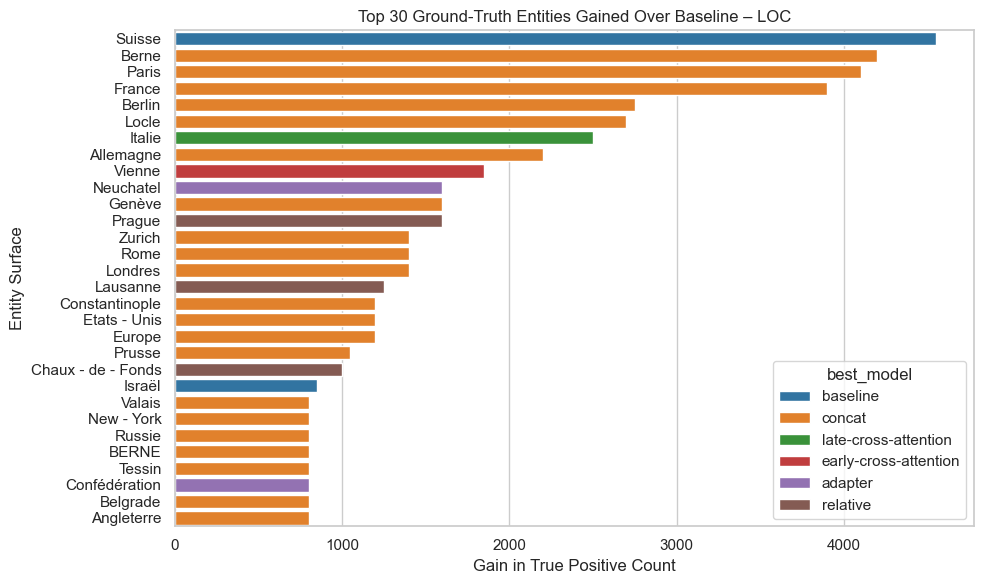

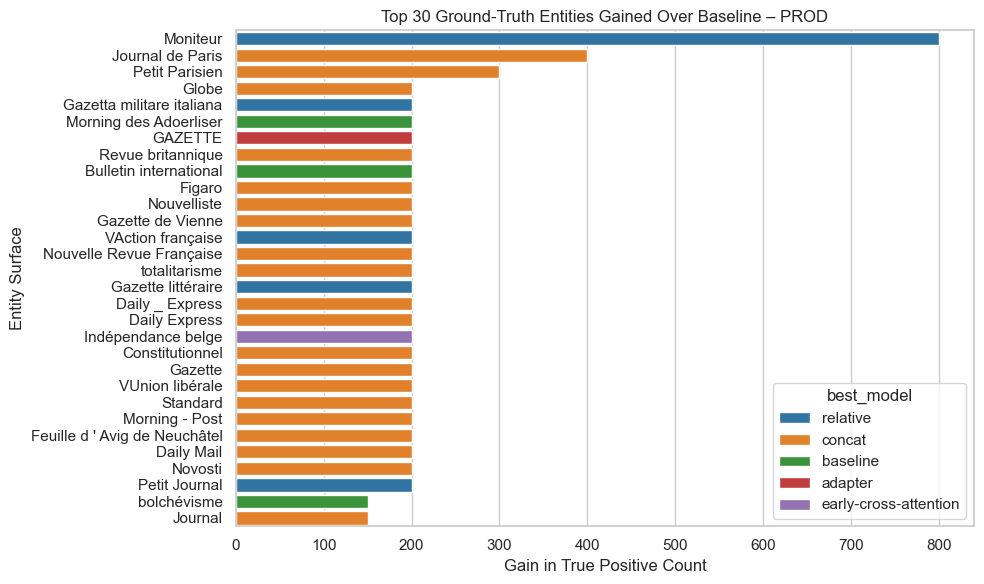

In [231]:
TOP_K = 30

for entity_type in entity_surface_df["type"].unique():
    subset = entity_surface_df[entity_surface_df["type"] == entity_type]
    top_gain = subset.sort_values("gain_vs_baseline", ascending=False).head(TOP_K)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top_gain,
        x="gain_vs_baseline",
        y="surface",
        hue="best_model",
        dodge=False,
        palette="tab10"
    )
    plt.title(f"Top {TOP_K} Ground-Truth Entities Gained Over Baseline – {entity_type.upper()}")
    plt.xlabel("Gain in True Positive Count")
    plt.ylabel("Entity Surface")
    plt.tight_layout()
    plt.savefig(f"true_gain_vs_baseline_{entity_type}.png", dpi=300)
    plt.show()

In [236]:
all_predictions.head()

,experiment,model,model_type,base_model,max_len,is_relative_time,time_bin_type,time_bin,entities,TP,FP,FN,precision,recall,f1,relative_year,temporal_mode,strategy
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"[Entity(surface='G R E E F E', type='loc', sub...",34,16,11,0.680000,0.755556,0.715789,False,Absolute,Late Fusion Strategies
1,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1808,"[Entity(surface='G R E E F E', type='loc', sub...",49,24,13,0.671233,0.790323,0.725926,False,Absolute,Late Fusion Strategies
2,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1818,"[Entity(surface='G R E E F E', type='loc', sub...",39,22,26,0.639344,0.600000,0.619048,False,Absolute,Late Fusion Strategies
3,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1828,"[Entity(surface='G R E E F E', type='loc', sub...",79,71,38,0.526667,0.675214,0.591760,False,Absolute,Late Fusion Strategies
4,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1838,"[Entity(surface='G R E E F E', type='loc', sub...",8,0,0,1.000000,1.000000,1.000000,False,Absolute,Late Fusion Strategies


In [237]:
from collections import Counter, defaultdict
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Index ground truth
gt_index = Counter((e.surface, e.type) for e in entities_gt)

# Step 2: Count true positives per model
model_tp_counter = defaultdict(Counter)

for exp in all_predictions["experiment"].unique():
    df_exp = all_predictions[all_predictions["experiment"] == exp]
    model = df_exp["strategy"].iloc[0]

    for _, row in df_exp.iterrows():
        for pred in row["entities"]:
            key = (pred.surface, pred.type)
            if key in gt_index:
                model_tp_counter[model][key] += 1

# Step 3: Compare against baseline
entity_surface_stats = []
baseline_model = "swiglu.baseline.True"

for (surface, typ) in gt_index:
    baseline_tp = model_tp_counter[baseline_model][(surface, typ)]
    max_tp = max(model_tp_counter[m][(surface, typ)] for m in model_tp_counter)
    best_model = max(model_tp_counter, key=lambda m: model_tp_counter[m][(surface, typ)])
    gain = max_tp - baseline_tp

    entity_surface_stats.append({
        "surface": surface,
        "type": typ,
        "baseline_tp": baseline_tp,
        "max_tp": max_tp,
        "gain_vs_baseline": gain,
        "best_model": best_model
    })

entity_surface_df = pd.DataFrame(entity_surface_stats)

In [241]:
entity_surface_df.best_model.unique()

array(['Late Fusion Strategies', 'Early Fusion Strategies', 'Baseline'],
      dtype=object)

In [238]:
entity_surface_df

,surface,type,baseline_tp,max_tp,gain_vs_baseline,best_model
0,Charlotte née Bourgoin,pers,0,650,650,Late Fusion Strategies
1,Joseph Digiez,pers,0,800,800,Late Fusion Strategies
2,Maurice Bourgoin,pers,0,400,400,Late Fusion Strategies
3,sieur Jaques Charles Gicot,pers,0,200,200,Late Fusion Strategies
4,Conseil d ' Etat,org,0,400,400,Late Fusion Strategies
...,...,...,...,...,...,...
1101,Floride,loc,0,800,800,Late Fusion Strategies
1102,Donald Trump,pers,0,800,800,Late Fusion Strategies
1103,ONU,org,0,400,400,Late Fusion Strategies
1104,Sénégal,loc,0,800,800,Late Fusion Strategies


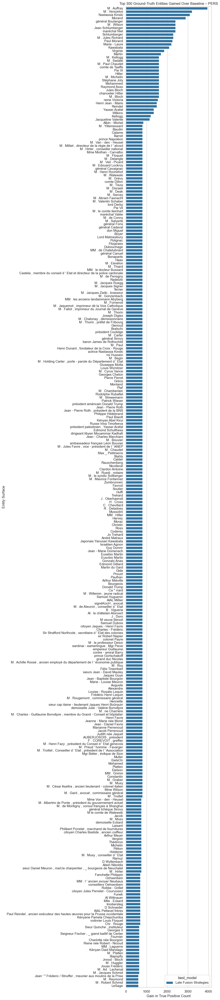

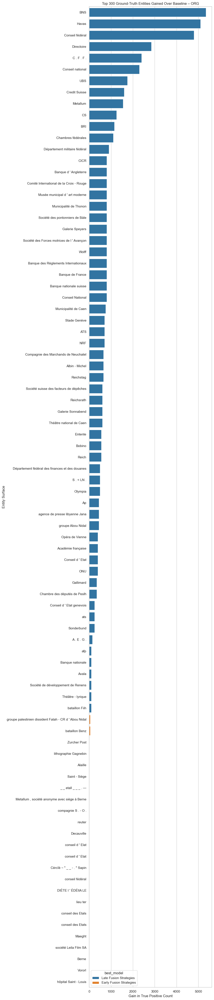

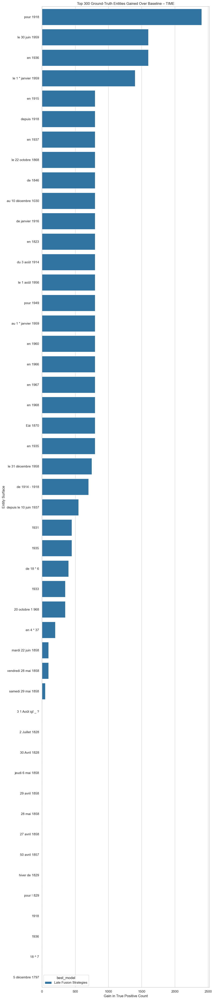

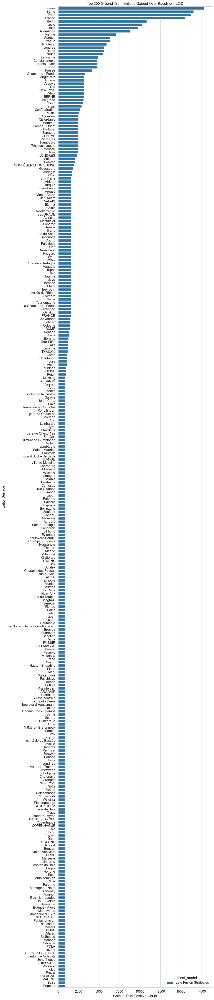

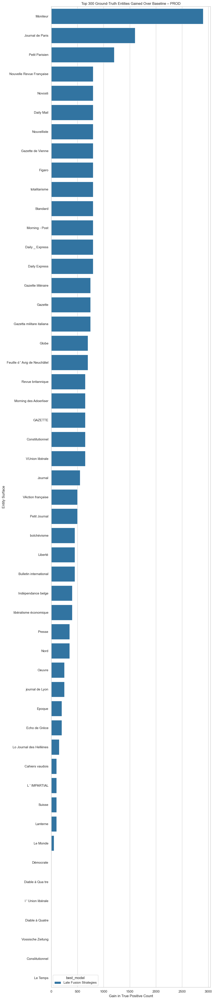

In [244]:
TOP_K = 300

for entity_type in entity_surface_df["type"].unique():
    subset = entity_surface_df[entity_surface_df["type"] == entity_type]
    top_gain = subset.sort_values("gain_vs_baseline", ascending=False).head(TOP_K)

    plt.figure(figsize=(10, 46))
    sns.barplot(
        data=top_gain,
        x="gain_vs_baseline",
        y="surface",
        hue="best_model",
        dodge=False,
        palette="tab10"
    )
    plt.title(f"Top {TOP_K} Ground-Truth Entities Gained Over Baseline – {entity_type.upper()}")
    plt.xlabel("Gain in True Positive Count")
    plt.ylabel("Entity Surface")
    plt.tight_layout()
    plt.savefig(f"true_gain_vs_baseline_{entity_type}.png", dpi=300)
    plt.show()

In [193]:
import pandas as pd

# Step 1: Explode entities so each entity is a row
df = all_predictions.copy()
df = df.explode("entities").dropna(subset=["entities"])

# Step 2: Extract entity type from the Entity object
df["entity_type"] = df["entities"].apply(lambda e: e.type if hasattr(e, "type") else None)
df = df.dropna(subset=["entity_type", "f1"])
df

,experiment,model,model_type,base_model,max_len,is_relative_time,time_bin_type,time_bin,entities,TP,FP,FN,precision,recall,f1,relative_year,temporal_mode,entity_type
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"Entity(surface='G R E E F E', type='loc', subt...",34,16,11,0.680000,0.755556,0.715789,False,Absolute,loc
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"Entity(surface='Charlotte née Bourgoin', type=...",34,16,11,0.680000,0.755556,0.715789,False,Absolute,pers
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"Entity(surface='Joseph Digiez', type='pers', s...",34,16,11,0.680000,0.755556,0.715789,False,Absolute,pers
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"Entity(surface='Maurice Bourgoin , enfant mine...",34,16,11,0.680000,0.755556,0.715789,False,Absolute,pers
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,Entity(surface='sieur Jaques Charles Gicot son...,34,16,11,0.680000,0.755556,0.715789,False,Absolute,pers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199,model_bert_base_multilingual_cased_max_sequenc...,adapter,time-based,bert_base_multilingual_cased,512,True,century,21th c.,"Entity(surface='Donald Trump', type='pers', su...",49,5,9,0.907407,0.844828,0.875000,True,Time Distance,pers
1199,model_bert_base_multilingual_cased_max_sequenc...,adapter,time-based,bert_base_multilingual_cased,512,True,century,21th c.,"Entity(surface='Etats - Unis', type='loc', sub...",49,5,9,0.907407,0.844828,0.875000,True,Time Distance,loc
1199,model_bert_base_multilingual_cased_max_sequenc...,adapter,time-based,bert_base_multilingual_cased,512,True,century,21th c.,"Entity(surface='ONU', type='org', subtype='org...",49,5,9,0.907407,0.844828,0.875000,True,Time Distance,org
1199,model_bert_base_multilingual_cased_max_sequenc...,adapter,time-based,bert_base_multilingual_cased,512,True,century,21th c.,"Entity(surface='Sénégal', type='loc', subtype=...",49,5,9,0.907407,0.844828,0.875000,True,Time Distance,loc


     entity_type     year                  model time_bin_type        f1
0            loc    1790s                adapter        decade  0.695737
1            loc    1790s               baseline        decade  0.714834
2            loc    1790s                 concat        decade  0.720404
3            loc    1790s  early-cross-attention        decade  0.672075
4            loc    1790s   late-cross-attention        decade  0.734403
...          ...      ...                    ...           ...       ...
1495        time  21th c.               baseline       century  0.871241
1496        time  21th c.                 concat       century  0.889903
1497        time  21th c.  early-cross-attention       century  0.877465
1498        time  21th c.   late-cross-attention       century  0.865080
1499        time  21th c.               relative       century  0.882568

[1500 rows x 5 columns]


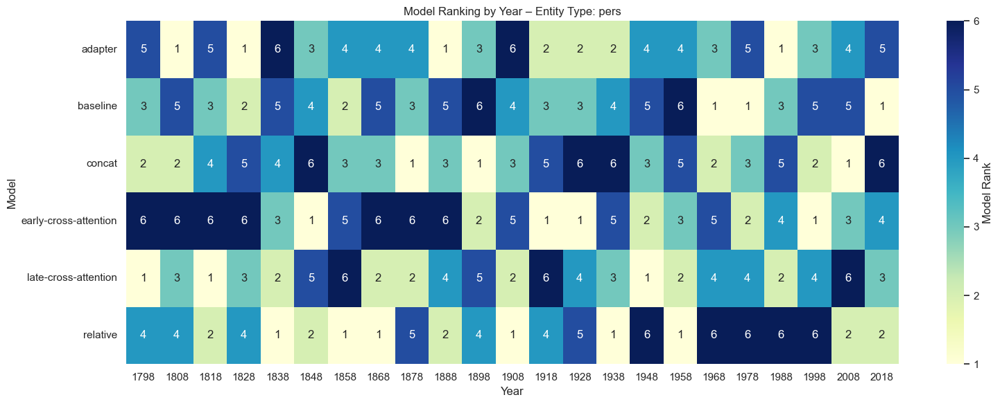

In [194]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Expand entities list into rows per entity type
expanded_rows = []
for _, row in all_predictions.iterrows():
    year = row["time_bin"]
    model = row["model"]
    for entity in row["entities"]:
        expanded_rows.append({
            "year": year,
            "model": model,
            "entity_type": entity.type
        })

entity_df = pd.DataFrame(expanded_rows)

# Step 2: Merge F1 scores from original df into expanded df
f1_data = all_predictions[["time_bin", "model", "f1", "time_bin_type"]].copy()
f1_data = f1_data.rename(columns={"time_bin": "year"})
entity_df = entity_df.merge(f1_data, on=["year", "model"], how="left")

# Step 3: Average F1 per model / year / entity_type
grouped = (
    entity_df.groupby(["entity_type", "year", "model", "time_bin_type"])["f1"]
    .mean()
    .reset_index()
)
print(grouped)
grouped = grouped[grouped["time_bin_type"] == "year"]

# Step 4: Pivot to get F1 scores per model
rank_df = grouped.pivot_table(index=["entity_type", "year"], columns="model", values="f1")

# Step 5: Rank models per year and entity
rankings = rank_df.rank(axis=1, ascending=False, method="min")

# Optional: choose one entity type to plot
entity_to_plot = "pers"
heat_data = rankings.loc[entity_to_plot].T  # transpose for heatmap: models x years

# Step 6: Plot
plt.figure(figsize=(16, 6))
sns.heatmap(heat_data, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={"label": "Model Rank"})
plt.title(f"Model Ranking by Year – Entity Type: {entity_to_plot}")
plt.xlabel("Year")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

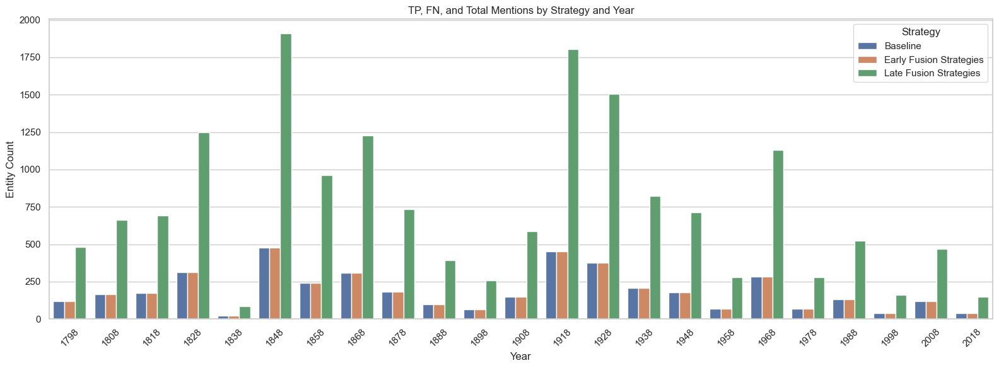

In [195]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Strategy map
strategy_map = {
    "baseline": "Baseline",
    "early-cross-attention": "Early Fusion Strategies",
    "late-cross-attention": "Late Fusion Strategies",
    "relative": "Late Fusion Strategies",
    "adapter": "Late Fusion Strategies",
    "concat": "Late Fusion Strategies",
    "film": "Late Fusion Strategies"
}

all_predictions["strategy"] = all_predictions["model"].map(strategy_map)

# Filter: only year-level bins
yearly_data = all_predictions[all_predictions["time_bin_type"] == "year"]

# Aggregate: TP, FN, and derived total mentions
grouped = (
    yearly_data
    .groupby(["strategy", "time_bin"])
    .agg(TP=("TP", "sum"), FN=("FN", "sum"))
    .reset_index()
)
grouped["Total Mentions"] = grouped["TP"] + grouped["FN"]

# Melt for bar plotting
melted = pd.melt(
    grouped,
    id_vars=["strategy", "time_bin"],
    value_vars=["TP", "FN", "Total Mentions"],
    var_name="Metric",
    value_name="Count"
)

# Plot
plt.figure(figsize=(16, 6))
sns.barplot(
    data=melted,
    x="time_bin", y="Count",
    hue="strategy",
    # palette={"baseline": "gray", "early": "blue", "late": "green"},
    dodge=True,
    errorbar=None
)
plt.title("TP, FN, and Total Mentions by Strategy and Year")
plt.xlabel("Year")
plt.ylabel("Entity Count")
plt.xticks(rotation=45)
plt.grid(True, axis="y")
plt.legend(title="Strategy")
plt.tight_layout()
plt.show()


1. Late fusion dominates in raw total mentions (TP + FN) across all years.
	•	The green bars (late fusion) are consistently much taller, showing it is handling more total entities.
	•	This confirms that late fusion models are recognizing significantly more candidates than early or baseline strategies.

2. Early fusion outperforms baseline in most years.
	•	The blue bars (early fusion) are mostly taller than the gray (baseline), indicating it detects more.

3. Baseline is the most conservative, with the fewest detected entities.
	•	Likely due to being temporally unaware, which aligns with expectations.


In [196]:
all_predictions.iloc[0].entities[:2]

[Entity(surface='G R E E F E', type='loc', subtype='', name='', title='', function='', wkd_id='_', date=datetime.datetime(1798, 1, 4, 0, 0)),
 Entity(surface='Charlotte née Bourgoin', type='pers', subtype='pers.ind', name='Bourgoin', title='', function='', wkd_id='NIL', date=datetime.datetime(1798, 1, 4, 0, 0))]

        model time_bin entity_type  avg_surface_len  std_surface_len  count
0     adapter     1798         loc         8.387420         4.369661   3291
1     adapter     1798         org        13.133462         9.535104    517
2     adapter     1798        pers        17.768186        14.534625   2062
3     adapter     1798        prod        12.551220         6.158333    205
4     adapter     1798        time        12.476395         5.982057    233
..        ...      ...         ...              ...              ...    ...
685  relative     2018         loc         8.359361         4.415355   3253
686  relative     2018         org        13.308468         9.862264    496
687  relative     2018        pers        17.437321        14.211395   2090
688  relative     2018        prod        12.453659         6.334936    205
689  relative     2018        time        11.887931         5.826156    232

[690 rows x 6 columns]


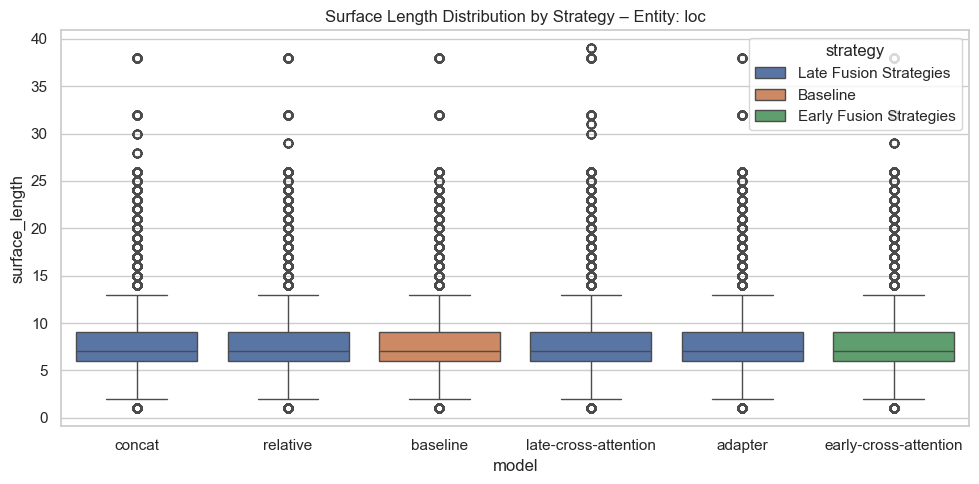

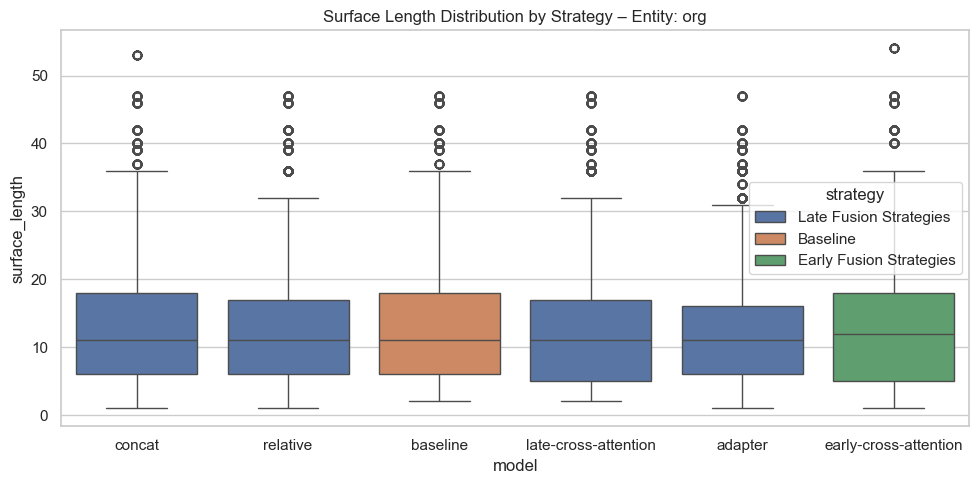

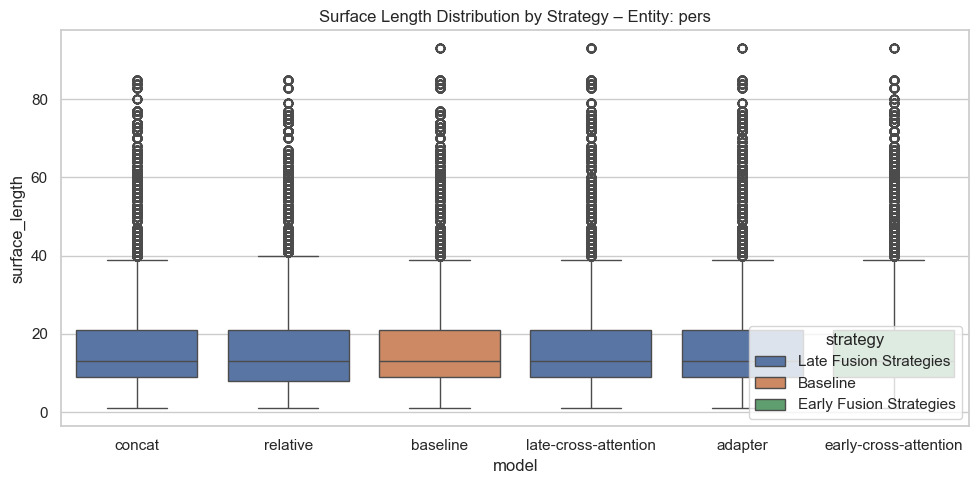

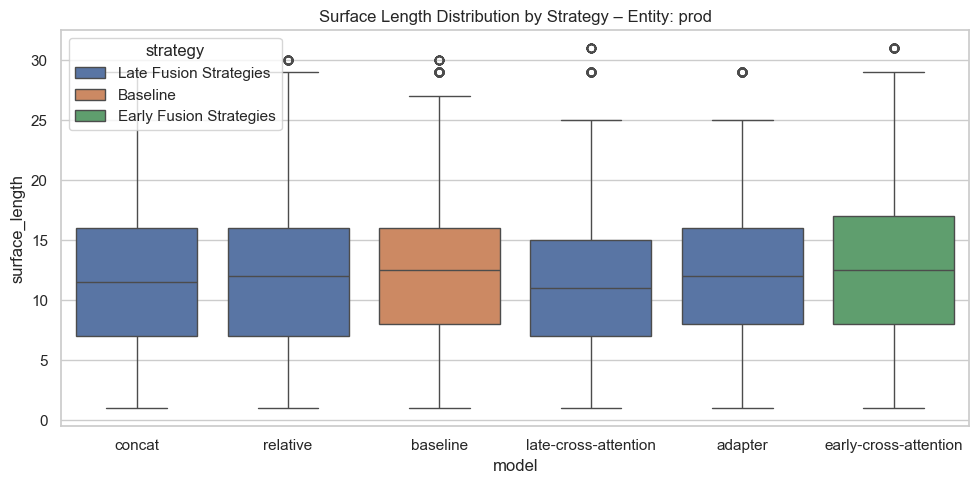

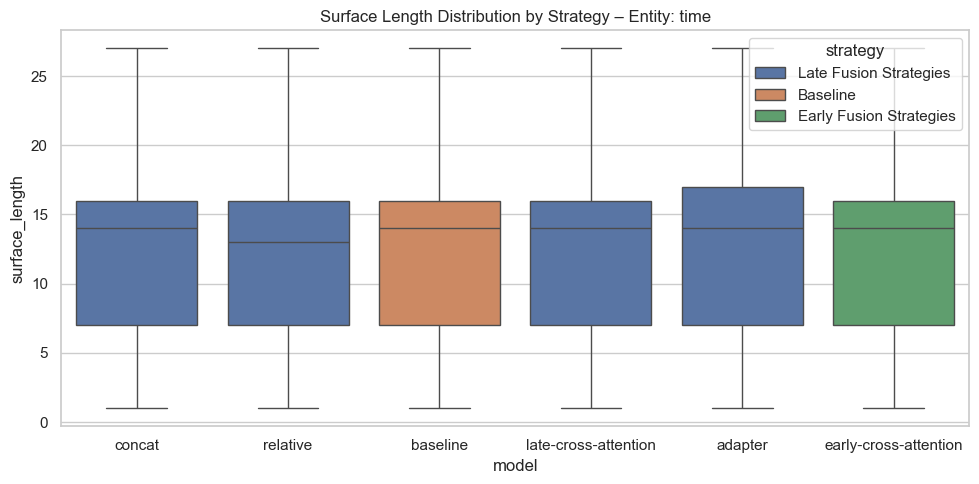

In [197]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Map model to strategy
strategy_map = {
    "baseline": "Baseline",
    "early-cross-attention": "Early Fusion Strategies",
    "late-cross-attention": "Late Fusion Strategies",
    "relative": "Late Fusion Strategies",
    "adapter": "Late Fusion Strategies",
    "concat": "Late Fusion Strategies",
    "film": "Late Fusion Strategies"
}
all_predictions["strategy"] = all_predictions["model"].map(strategy_map)

# Filter to year bins and explode entities
yearly_data = all_predictions[all_predictions["time_bin_type"] == "year"].copy()
exploded = yearly_data.explode("entities")

# Extract surface length and entity type
exploded["surface_length"] = exploded["entities"].apply(
    lambda e: len(e.surface) if e is not None and hasattr(e, "surface") else None
)
exploded["entity_type"] = exploded["entities"].apply(
    lambda e: e.type if e is not None and hasattr(e, "type") else None
)
# print(exploded)
# Drop nulls
filtered = exploded.dropna(subset=["surface_length", "strategy", "entity_type", "time_bin"])

# Group: avg surface length per year, strategy, entity type
grouped = (
    filtered.groupby(["model", "time_bin", "entity_type"])
    .agg(avg_surface_len=("surface_length", "mean"),
         std_surface_len=("surface_length", "std"),
         count=("surface_length", "count"))
    .reset_index()
)
print(grouped)

# Plot per entity_type
for entity in sorted(filtered["entity_type"].unique()):
    subset = filtered[filtered["entity_type"] == entity]
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=subset,
        x="model", y="surface_length",
        # palette={"baseline": "gray", "early": "blue", "late": "green"},
        hue="strategy"
    )
    plt.title(f"Surface Length Distribution by Strategy – Entity: {entity}")
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

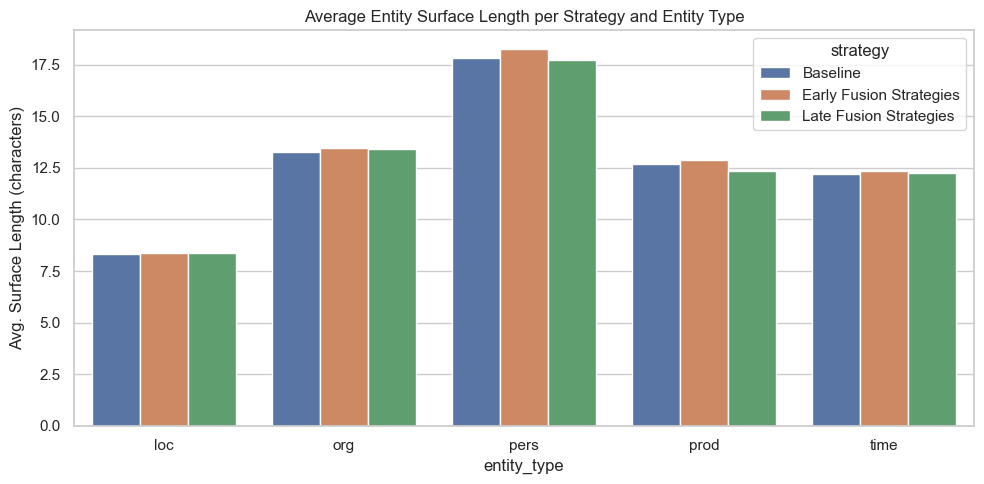

In [198]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group mean ± std surface length by strategy + entity type
grouped_avg = (
    filtered.groupby(["strategy", "entity_type"])
    .agg(avg_surface_len=("surface_length", "mean"),
         std_surface_len=("surface_length", "std"),
         count=("surface_length", "count"))
    .reset_index()
)

# Plot per entity type
plt.figure(figsize=(10, 5))
sns.barplot(
    data=grouped_avg,
    x="entity_type", y="avg_surface_len", hue="strategy",
    # palette={"baseline": "gray", "early": "blue", "late": "green"},
    errorbar="sd"
)
plt.title("Average Entity Surface Length per Strategy and Entity Type")
plt.ylabel("Avg. Surface Length (characters)")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

    time_bin                 strategy length_category        f1
0      1790s                 Baseline            long  0.715086
1      1790s                 Baseline          medium  0.714892
2      1790s                 Baseline           short  0.715605
3      1790s  Early Fusion Strategies            long  0.672269
4      1790s  Early Fusion Strategies          medium  0.671703
..       ...                      ...             ...       ...
202    2010s  Early Fusion Strategies          medium  0.904948
203    2010s  Early Fusion Strategies           short  0.905650
204    2010s   Late Fusion Strategies            long  0.904955
205    2010s   Late Fusion Strategies          medium  0.904719
206    2010s   Late Fusion Strategies           short  0.905613

[207 rows x 4 columns]


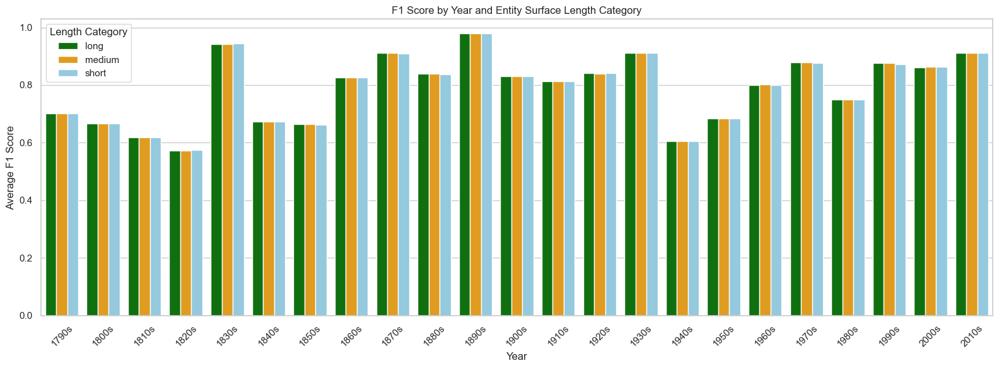

In [199]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Map models to strategy
strategy_map = {
    "baseline": "Baseline",
    "early-cross-attention": "Early Fusion Strategies",
    "late-cross-attention": "Late Fusion Strategies",
    "relative": "Late Fusion Strategies",
    "adapter": "Late Fusion Strategies",
    "concat": "Late Fusion Strategies",
    "film": "Late Fusion Strategies"
}
all_predictions["strategy"] = all_predictions["model"].map(strategy_map)

# Step 2: Explode entities
df = all_predictions.copy()
df = df[df["time_bin_type"] == "decade"].explode("entities")

# Step 3: Extract surface length and entity type
df["surface_length"] = df["entities"].apply(
    lambda e: len(e.surface) if e is not None and hasattr(e, "surface") else None
)

# Step 4: Categorize by length
def categorize_length(length):
    if length is None:
        return None
    elif length <= 3:
        return "short"
    elif length <= 10:
        return "medium"
    else:
        return "long"

df["length_category"] = df["surface_length"].apply(categorize_length)
# print(df)
# Step 5: Group and compute average F1 per year, length category, strategy
grouped = (
    df.groupby(["time_bin", "strategy", "length_category"])["f1"]
    .mean()
    .reset_index()
)
print(grouped)

# Step 6: Plot
plt.figure(figsize=(16, 6))
sns.barplot(
    data=grouped,
    x="time_bin",
    y="f1",
    hue="length_category",
    palette={"short": "skyblue", "medium": "orange", "long": "green"},
    errorbar=None
)
plt.title("F1 Score by Year and Entity Surface Length Category")
plt.xlabel("Year")
plt.ylabel("Average F1 Score")
plt.xticks(rotation=45)
plt.legend(title="Length Category")
plt.tight_layout()
plt.show()


In [200]:
exploded.head()


,experiment,model,model_type,base_model,max_len,is_relative_time,time_bin_type,time_bin,entities,TP,FP,FN,precision,recall,f1,relative_year,temporal_mode,strategy,surface_length,entity_type
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"Entity(surface='G R E E F E', type='loc', subt...",34,16,11,0.68,0.755556,0.715789,False,Absolute,Late Fusion Strategies,11,loc
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"Entity(surface='Charlotte née Bourgoin', type=...",34,16,11,0.68,0.755556,0.715789,False,Absolute,Late Fusion Strategies,22,pers
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"Entity(surface='Joseph Digiez', type='pers', s...",34,16,11,0.68,0.755556,0.715789,False,Absolute,Late Fusion Strategies,13,pers
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"Entity(surface='Maurice Bourgoin , enfant mine...",34,16,11,0.68,0.755556,0.715789,False,Absolute,Late Fusion Strategies,32,pers
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,Entity(surface='sieur Jaques Charles Gicot son...,34,16,11,0.68,0.755556,0.715789,False,Absolute,Late Fusion Strategies,39,pers


In [201]:
filtered

,experiment,model,model_type,base_model,max_len,is_relative_time,time_bin_type,time_bin,entities,TP,FP,FN,precision,recall,f1,relative_year,temporal_mode,strategy,surface_length,entity_type
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"Entity(surface='G R E E F E', type='loc', subt...",34,16,11,0.680000,0.755556,0.715789,False,Absolute,Late Fusion Strategies,11,loc
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"Entity(surface='Charlotte née Bourgoin', type=...",34,16,11,0.680000,0.755556,0.715789,False,Absolute,Late Fusion Strategies,22,pers
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"Entity(surface='Joseph Digiez', type='pers', s...",34,16,11,0.680000,0.755556,0.715789,False,Absolute,Late Fusion Strategies,13,pers
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"Entity(surface='Maurice Bourgoin , enfant mine...",34,16,11,0.680000,0.755556,0.715789,False,Absolute,Late Fusion Strategies,32,pers
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,Entity(surface='sieur Jaques Charles Gicot son...,34,16,11,0.680000,0.755556,0.715789,False,Absolute,Late Fusion Strategies,39,pers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551,model_bert_base_multilingual_cased_max_sequenc...,adapter,time-based,bert_base_multilingual_cased,512,True,year,2018,"Entity(surface='Donald Trump', type='pers', su...",12,1,2,0.923077,0.857143,0.888889,True,Time Distance,Late Fusion Strategies,12,pers
551,model_bert_base_multilingual_cased_max_sequenc...,adapter,time-based,bert_base_multilingual_cased,512,True,year,2018,"Entity(surface='Etats - Unis', type='loc', sub...",12,1,2,0.923077,0.857143,0.888889,True,Time Distance,Late Fusion Strategies,12,loc
551,model_bert_base_multilingual_cased_max_sequenc...,adapter,time-based,bert_base_multilingual_cased,512,True,year,2018,"Entity(surface='ONU', type='org', subtype='org...",12,1,2,0.923077,0.857143,0.888889,True,Time Distance,Late Fusion Strategies,3,org
551,model_bert_base_multilingual_cased_max_sequenc...,adapter,time-based,bert_base_multilingual_cased,512,True,year,2018,"Entity(surface='Sénégal', type='loc', subtype=...",12,1,2,0.923077,0.857143,0.888889,True,Time Distance,Late Fusion Strategies,7,loc


                                          experiment   model  model_type  \
0  model_dbmdz_bert_base_historic_multilingual_ca...  concat  time-based   
0  model_dbmdz_bert_base_historic_multilingual_ca...  concat  time-based   
0  model_dbmdz_bert_base_historic_multilingual_ca...  concat  time-based   
0  model_dbmdz_bert_base_historic_multilingual_ca...  concat  time-based   
0  model_dbmdz_bert_base_historic_multilingual_ca...  concat  time-based   

                 base_model max_len  is_relative_time time_bin_type time_bin  \
0  dbmdz_bert_base_historic     512             False          year     1798   
0  dbmdz_bert_base_historic     512             False          year     1798   
0  dbmdz_bert_base_historic     512             False          year     1798   
0  dbmdz_bert_base_historic     512             False          year     1798   
0  dbmdz_bert_base_historic     512             False          year     1798   

                                            entities  TP  ... 

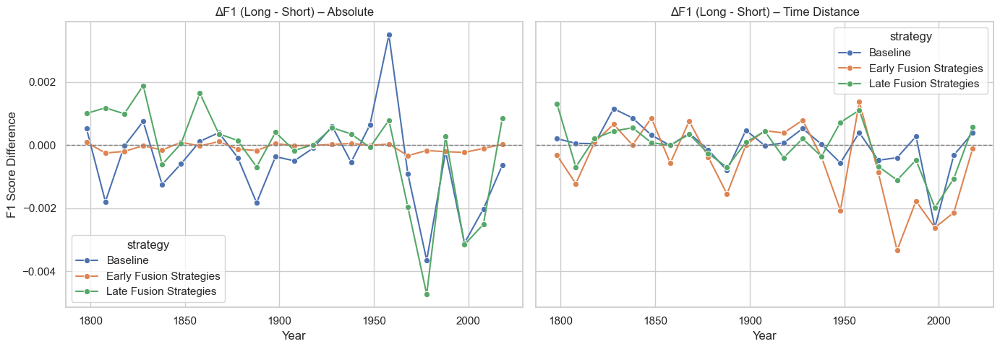

In [202]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'exploded' is your DataFrame with exploded entities
# and 'strategy_map' is already defined and mapped to exploded['strategy']

# Compute surface length and entity type
exploded["surface_length"] = exploded["entities"].apply(
    lambda e: len(e.surface) if e and hasattr(e, "surface") else None
)
exploded["entity_type"] = exploded["entities"].apply(
    lambda e: e.type if e and hasattr(e, "type") else None
)

# Drop rows with missing surface lengths
filtered = exploded.dropna(subset=["surface_length", "strategy", "entity_type", "time_bin"])

# Bin entity lengths
def categorize_length(length):
    if length <= 10:
        return "short"
    elif length <= 20:
        return "medium"
    else:
        return "long"

filtered["length_category"] = filtered["surface_length"].apply(categorize_length)
print(filtered.head())
# Compute average F1 per group
length_performance_df = (
    filtered.groupby(["time_bin", "strategy", "length_category", "temporal_mode"])
    .agg(f1=("f1", "mean"))
    .reset_index()
)

# Pivot for delta computation
pivot_df = length_performance_df.pivot_table(
    index=["time_bin", "strategy", "temporal_mode"],
    columns="length_category",
    values="f1"
).reset_index()

# Compute delta
pivot_df["delta_f1_long_short"] = pivot_df["long"] - pivot_df["short"]
pivot_df["time_bin"] = pivot_df["time_bin"].astype(int)

# Plot ΔF1 (Long - Short) per temporal_mode
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

temporal_modes = pivot_df["temporal_mode"].unique()
for ax, mode in zip(axes, temporal_modes):
    subset = pivot_df[pivot_df["temporal_mode"] == mode]
    sns.lineplot(
        data=subset,
        x="time_bin",
        y="delta_f1_long_short",
        hue="strategy",
        marker="o",
        ax=ax
    )
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"ΔF1 (Long - Short) – {mode}")
    ax.set_xlabel("Year")
    ax.set_ylabel("F1 Score Difference")
    ax.grid(True)
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig("../images/delta_f1_long_short_by_strategy_and_mode.png", dpi=300)
plt.show()


✅ What It Shows:
	•	Positive ΔF1 means the strategy performs better on long entities.
	•	Negative ΔF1 means it performs better on short entities.
	•	Lines close to 0 mean the strategy performs equally well on both.

🧠 Observations:
	•	The differences are extremely small, mostly hovering around 0.0–0.005.
	•	Late fusion tends to be slightly more favorable to long entities in a few years.
	•	There is no significant variation across strategies—indicating that all strategies treat short and long entities similarly in terms of F1.

⏭️ Suggested Next Steps:

To make these differences more meaningful:
	1.	Switch to recall or precision instead of F1 — they may vary more per length.
	2.	Aggregate by decade to reduce noise.
	3.	Plot boxplots of F1 by length category instead of deltas for visual clarity.
	4.	Compare error types (e.g., FN counts) across lengths.



In [203]:
exploded

,experiment,model,model_type,base_model,max_len,is_relative_time,time_bin_type,time_bin,entities,TP,FP,FN,precision,recall,f1,relative_year,temporal_mode,strategy,surface_length,entity_type
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"Entity(surface='G R E E F E', type='loc', subt...",34,16,11,0.680000,0.755556,0.715789,False,Absolute,Late Fusion Strategies,11,loc
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"Entity(surface='Charlotte née Bourgoin', type=...",34,16,11,0.680000,0.755556,0.715789,False,Absolute,Late Fusion Strategies,22,pers
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"Entity(surface='Joseph Digiez', type='pers', s...",34,16,11,0.680000,0.755556,0.715789,False,Absolute,Late Fusion Strategies,13,pers
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,"Entity(surface='Maurice Bourgoin , enfant mine...",34,16,11,0.680000,0.755556,0.715789,False,Absolute,Late Fusion Strategies,32,pers
0,model_dbmdz_bert_base_historic_multilingual_ca...,concat,time-based,dbmdz_bert_base_historic,512,False,year,1798,Entity(surface='sieur Jaques Charles Gicot son...,34,16,11,0.680000,0.755556,0.715789,False,Absolute,Late Fusion Strategies,39,pers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551,model_bert_base_multilingual_cased_max_sequenc...,adapter,time-based,bert_base_multilingual_cased,512,True,year,2018,"Entity(surface='Donald Trump', type='pers', su...",12,1,2,0.923077,0.857143,0.888889,True,Time Distance,Late Fusion Strategies,12,pers
551,model_bert_base_multilingual_cased_max_sequenc...,adapter,time-based,bert_base_multilingual_cased,512,True,year,2018,"Entity(surface='Etats - Unis', type='loc', sub...",12,1,2,0.923077,0.857143,0.888889,True,Time Distance,Late Fusion Strategies,12,loc
551,model_bert_base_multilingual_cased_max_sequenc...,adapter,time-based,bert_base_multilingual_cased,512,True,year,2018,"Entity(surface='ONU', type='org', subtype='org...",12,1,2,0.923077,0.857143,0.888889,True,Time Distance,Late Fusion Strategies,3,org
551,model_bert_base_multilingual_cased_max_sequenc...,adapter,time-based,bert_base_multilingual_cased,512,True,year,2018,"Entity(surface='Sénégal', type='loc', subtype=...",12,1,2,0.923077,0.857143,0.888889,True,Time Distance,Late Fusion Strategies,7,loc


In [210]:
len(exploded[exploded['time_bin'] == 1798]), len(exploded[exploded['time_bin'] == 2018])

(37580, 37580)

In [205]:
len(exploded)

864340

In [206]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure time_bin is integer
exploded["time_bin"] = exploded["time_bin"].astype(int)

# Count number of non-null entities per year
entity_counts = (
    exploded[exploded["entities"].notnull()]
    .groupby("time_bin")
    .size()
    .reset_index(name="entity_count")
)

In [207]:
entity_counts

,time_bin,entity_count
0,1798,37580
1,1808,37580
2,1818,37580
3,1828,37580
4,1838,37580
5,1848,37580
6,1858,37580
7,1868,37580
8,1878,37580
9,1888,37580


In [208]:
all_predictions.iloc[0].entities[:3]

[Entity(surface='G R E E F E', type='loc', subtype='', name='', title='', function='', wkd_id='_', date=datetime.datetime(1798, 1, 4, 0, 0)),
 Entity(surface='Charlotte née Bourgoin', type='pers', subtype='pers.ind', name='Bourgoin', title='', function='', wkd_id='NIL', date=datetime.datetime(1798, 1, 4, 0, 0)),
 Entity(surface='Joseph Digiez', type='pers', subtype='pers.ind', name='Digiez', title='', function='', wkd_id='NIL', date=datetime.datetime(1798, 1, 4, 0, 0))]

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only yearly bins and drop nulls
pr_df = all_predictions[
    (all_predictions["time_bin_type"] == "century") &
    all_predictions["strategy"].notna()
][["strategy", "time_bin", "precision", "recall"]].copy()

# Drop rows with missing precision/recall
pr_df = pr_df.dropna()

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pr_df,
    x="recall", y="precision",
    hue="strategy",
    style="strategy",
    s=80
)

# Annotate with year for clarity
for _, row in pr_df.iterrows():
    plt.text(row["recall"] + 0.002, row["precision"] + 0.002, str(row["time_bin"]), fontsize=7)

plt.title("Precision vs. Recall Tradeoff by Strategy and Century")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Strategy map
strategy_map = {
    "baseline": "Baseline",
    "early-cross-attention": "Early Fusion Strategies",
    "late-cross-attention": "Late Fusion Strategies",
    "relative": "Late Fusion Strategies",
    "adapter": "Late Fusion Strategies",
    "concat": "Late Fusion Strategies",
    "film": "Late Fusion Strategies"
}
all_predictions["strategy"] = all_predictions["model"].map(strategy_map)

# Filter relevant columns
df = all_predictions[["precision", "recall", "time_bin_type", "strategy"]].dropna()
df = df[df["time_bin_type"] == "century"]

# Add century labels for annotation
df["century_label"] = df["time_bin_type"].apply(lambda x: f"{x}")

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="recall", y="precision", hue="strategy", style="strategy")

# Optional: Annotate if desired
# for _, row in df.iterrows():
#     plt.text(row["recall"] + 0.002, row["precision"], row["century_label"], fontsize=7)

plt.title("Precision vs. Recall Tradeoff by Strategy and Century")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Load the TSV file
df = pd.read_csv("../summary_results.tsv", sep="\t")
# Convert 'use_relative_year' column from string to boolean
df["use_relative_year"] = df["use_relative_year"].astype(str).str.lower() == "true"
df["temporal_mode"] = df["use_relative_year"].map({True: "Time Distance", False: "Absolute"})

# Basic statistics
print("\nAccuracy by Temporal Fusion Strategy:")

# Plot accuracy per strategy
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="temporal_fusion_strategy", y="mean_accuracy", hue="temporal_mode")
plt.title("Probing Accuracy by Temporal Fusion Strategy")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Best configuration
best_row = df.loc[df["mean_accuracy"].idxmax()]
print("\nBest performing model configuration:")
print(best_row)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import CategoricalDtype

# Load the TSV file
df = pd.read_csv("../summary_results.tsv", sep="\t")

# Convert to proper boolean and mode names
df["use_relative_year"] = df["use_relative_year"].astype(str).str.lower() == "true"
df["temporal_mode"] = df["use_relative_year"].map({True: "Time Distance", False: "Absolute"})

# Define fusion type map
fusion_type_map = {
    "baseline": "Baseline",
    "early-cross-attention": "Early Fusion Strategies",
    "late-cross-attention": "Late Fusion Strategies",
    "adapter": "Late Fusion Strategies",
    "concat": "Late Fusion Strategies",
    "relative": "Late Fusion Strategies"
}
df["fusion_type"] = df["temporal_fusion_strategy"].map(fusion_type_map)

# Set category order
fusion_order = ["Baseline", "Early Fusion Strategies", "Late Fusion Strategies"]
strategy_order = ["baseline", "early-cross-attention", "late-cross-attention", "adapter", "concat", "relative"]

df["fusion_type"] = df["fusion_type"].astype(CategoricalDtype(categories=fusion_order, ordered=True))
df["temporal_fusion_strategy"] = df["temporal_fusion_strategy"].astype(CategoricalDtype(categories=strategy_order, ordered=True))

# Use colorblind-friendly palette
sns.set_palette("colorblind")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

# Fusion type plot
sns.barplot(data=df, x="fusion_type", y="mean_accuracy", hue="temporal_mode", ax=axes[0])
axes[0].set_title("Accuracy by Fusion Type")
axes[0].set_xlabel("Fusion Type")
axes[0].set_ylabel("Mean Accuracy")
axes[0].tick_params(axis='x', rotation=0)

# Strategy plot
sns.barplot(data=df, x="temporal_fusion_strategy", y="mean_accuracy", hue="temporal_mode", ax=axes[1])
axes[1].set_title("Accuracy by Fusion Strategy")
axes[1].set_xlabel("Fusion Strategy")
axes[1].set_ylabel("")  # Shared Y-axis
axes[1].tick_params(axis='x', rotation=10)

# Finalize and save
for ax in axes:
    ax.legend(title="Temporal Mode")
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("../images/probing_accuracy_comparison.png", dpi=300)
plt.show()

Key Takeaways from the Plot:
	•	Late Fusion models encode temporal information much more effectively than Early Fusion or Baseline models.
	•	Relative year encoding further boosts performance, suggesting that models benefit from temporally normalized input representations.
	•	Early Fusion underperforms dramatically, possibly because injecting temporal signals too early interferes with token-level semantics.


In [ ]:
all_predictions

In [ ]:
all_predictions.iloc[0].entities[:3]

In [ ]:
from collections import defaultdict

# Filter to year-based bins
baseline_df = all_predictions[(all_predictions["model"] == "baseline") & (all_predictions["time_bin_type"] == "year")]
late_df = all_predictions[(all_predictions["model"] == "late-cross-attention") & (all_predictions["time_bin_type"] == "year")]

baseline_df["time_bin"] = baseline_df["time_bin"].astype(int)
late_df["time_bin"] = late_df["time_bin"].astype(int)

# Group ground truth by year
gt_by_year = defaultdict(list)
for e in entities_gt:
    year = e.date.year
    gt_by_year[year].append(e)

# Collect missed entity surfaces by strategy
missed_by_strategy = defaultdict(lambda: defaultdict(set))  # {decade: {strategy: set of surfaces}}

for year in sorted(gt_by_year):
    decade = (year // 10) * 10
    gt_entities = gt_by_year[year]

    base_row = baseline_df[baseline_df["time_bin"] == year]
    late_row = late_df[late_df["time_bin"] == year]

    if base_row.empty or late_row.empty:
        continue

    base_preds = base_row.iloc[0]["entities"]
    late_preds = late_row.iloc[0]["entities"]

    # Find FN = entities in GT not found in predictions
    base_fn = {e.surface for e in gt_entities if e.surface not in {p.surface for p in base_preds}}
    late_fn = {e.surface for e in gt_entities if e.surface not in {p.surface for p in late_preds}}

    missed_by_strategy[decade]["baseline"].update(base_fn)
    missed_by_strategy[decade]["late-cross-attention"].update(late_fn)

from collections import defaultdict
import pandas as pd

# Prepare statistics per decade
stats = []
for decade in sorted(gt_by_year):
    decade_bin = (decade // 10) * 10
    gt_entities = {e.surface for e in gt_by_year[decade]}

    baseline_missed = missed_by_strategy[decade_bin].get("baseline", set())
    late_missed = missed_by_strategy[decade_bin].get("late-cross-attention", set())

    missed_by_both = baseline_missed & late_missed
    missed_only_baseline = baseline_missed - late_missed
    missed_only_late = late_missed - baseline_missed

    stats.append({
        "decade": decade_bin,
        "n_entities": len(gt_entities),
        "missed_baseline_only": len(missed_only_baseline),
        "missed_late_only": len(missed_only_late),
        "missed_by_both": len(missed_by_both)
    })

# Create DataFrame
decade_stats_df = pd.DataFrame(stats).sort_values("decade")

# Show
import pandas as pd

# Create DataFrame from missed_by_strategy
records = []
for decade in sorted(missed_by_strategy):
    baseline_set = missed_by_strategy[decade].get("baseline", set())
    late_set = missed_by_strategy[decade].get("late-cross-attention", set())

    common_missed = baseline_set & late_set
    baseline_only = baseline_set - late_set
    late_only = late_set - baseline_set

    records.append({
        "decade": decade,
        "baseline_missed": len(baseline_set),
        "late_missed": len(late_set),
        "common_missed": len(common_missed),
        "baseline_only": len(baseline_only),
        "late_only": len(late_only),
        "baseline_only_ratio": len(baseline_only) / max(1, len(baseline_set)),
        "late_only_ratio": len(late_only) / max(1, len(late_set)),
        "total_gt_entities": len(gt_by_year.get(decade, []))
    })

missed_stats_df = pd.DataFrame(records)

# Show the table
# Print example output and compare missed entities
for decade in sorted(missed_by_strategy):
    print(f"\n--- {decade}s ---")
    baseline_missed = missed_by_strategy[decade].get("baseline", set())
    late_missed = missed_by_strategy[decade].get("late-cross-attention", set())

    print(f"baseline: {len(baseline_missed)} missed entities")
    print(f"late-cross-attention: {len(late_missed)} missed entities")

    common = baseline_missed & late_missed
    only_baseline = baseline_missed - late_missed
    only_late = late_missed - baseline_missed

    print(f"common: {len(common)} entities missed by both")
    if common:
        print("  ▸ Common missed:")
        for entity in sorted(common):
            print(f"    - {entity}")

    print(f"only baseline: {len(only_baseline)} entities")
    if only_baseline:
        print("  ▸ Missed only by baseline:")
        for entity in sorted(only_baseline):
            print(f"    - {entity}")

    print(f"only late-cross-attention: {len(only_late)} entities")
    if only_late:
        print("  ▸ Missed only by late-cross-attention:")
        for entity in sorted(only_late):
            print(f"    - {entity}")

In [ ]:
entities_gt[:3]

In [ ]:
decade_stats_df.head()

In [ ]:
missed_stats_df.head()

In [ ]:
decade_stats_df["missed_baseline_only"].sum(), decade_stats_df["missed_late_only"].sum()

In [ ]:
missed_stats_df["baseline_missed"].sum(), missed_stats_df["late_missed"].sum()